# [[8,2,3]] Code Data Generation - Self-Contained

Fully self-contained implementation for syndrome data generation using the [[8,2,3]] code.
No local imports required - only reads the network graph pickle file.

**Code Properties:**
- **Physical qubits**: 8
- **Logical qubits**: 2
- **Distance**: 3
- **Stabilizers**: 6
- **Correctable errors**: Any single-qubit X, Y, or Z error

**Stabilizers:**
- K1 = XIIIYZZZ
- K2 = ZIIXIYII
- K3 = IXIZYXIX
- K4 = IZIYZXXY
- K5 = IIXYXZYZ
- K6 = IIZIIIYX

**Protocol:**
1. Encode two logical qubits at source using [[8,2,3]] code
2. SWAP encoded state along multi-hop path to sink
3. Measure syndrome at sink

No corrections applied - just raw syndrome observation.

In [5]:
# =============================================================================
# IMPORTS (External packages only)
# =============================================================================
from qiskit import QuantumCircuit, transpile, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel
from qiskit_ibm_runtime.fake_provider import FakeFez
from qiskit.visualization import plot_histogram

import numpy as np
import networkx as nx
import pickle
import os
from typing import Dict, List, Tuple
from itertools import combinations

## Qubit Mapping Constants

Physical qubit mapping for 8-node fully connected network with [[8,2,3]] code.

- **Node qubits**: 14 per node (8 data + 6 ancilla) = 112 qubits
- **Path qubits**: 1 per edge = 28 qubits (C(8,2) edges)
- **Total**: 140 qubits

In [6]:
# =============================================================================
# QUBIT MAPPING CONSTANTS
# =============================================================================

# Node qubits: 14 per node (8 data + 6 ancilla)
NODE_PHYSICAL_QUBITS_823: Dict[int, List[int]] = {
    0: list(range(0, 14)),      # Node 0 → physical qubits 0-13
    1: list(range(14, 28)),     # Node 1 → physical qubits 14-27
    2: list(range(28, 42)),     # Node 2 → physical qubits 28-41
    3: list(range(42, 56)),     # Node 3 → physical qubits 42-55
    4: list(range(56, 70)),     # Node 4 → physical qubits 56-69
    5: list(range(70, 84)),     # Node 5 → physical qubits 70-83
    6: list(range(84, 98)),     # Node 6 → physical qubits 84-97
    7: list(range(98, 112)),    # Node 7 → physical qubits 98-111
}

# Path qubits: 1 per edge for SWAP transport
# All 28 edges of a fully connected 8-node graph
PATH_PHYSICAL_QUBITS_823: Dict[Tuple[int, int], List[int]] = {
    # Node 0 edges
    (0, 1): [112],
    (0, 2): [113],
    (0, 3): [114],
    (0, 4): [115],
    (0, 5): [116],
    (0, 6): [117],
    (0, 7): [118],
    # Node 1 edges (excluding 0-1)
    (1, 2): [119],
    (1, 3): [120],
    (1, 4): [121],
    (1, 5): [122],
    (1, 6): [123],
    (1, 7): [124],
    # Node 2 edges (excluding 0-2, 1-2)
    (2, 3): [125],
    (2, 4): [126],
    (2, 5): [127],
    (2, 6): [128],
    (2, 7): [129],
    # Node 3 edges (excluding 0-3, 1-3, 2-3)
    (3, 4): [130],
    (3, 5): [131],
    (3, 6): [132],
    (3, 7): [133],
    # Node 4 edges (excluding all above)
    (4, 5): [134],
    (4, 6): [135],
    (4, 7): [136],
    # Node 5 edges (excluding all above)
    (5, 6): [137],
    (5, 7): [138],
    # Node 6 edges (excluding all above)
    (6, 7): [139],
}

# Total qubits: 112 (nodes) + 28 (paths) = 140
TOTAL_QUBITS_823: int = 140

# [[8,2,3]] Stabilizer generators
STABILIZERS_823 = [
    "XIIIYZZZ",
    "ZIIXIYII",
    "IXIZYXIX",
    "IZIYZXXY",
    "IIXYXZYZ",
    "IIZIIIYX",
]

# Number of syndromes: 2^6 = 64
NUM_SYNDROMES_823 = 64

print(f"Qubit mapping: {len(NODE_PHYSICAL_QUBITS_823)} nodes, {len(PATH_PHYSICAL_QUBITS_823)} edges")
print(f"Qubits per node: 14 (8 data + 6 ancilla)")
print(f"Total qubits: {TOTAL_QUBITS_823}")
print(f"Number of stabilizers: {len(STABILIZERS_823)}")
print(f"Number of syndromes: {NUM_SYNDROMES_823}")

Qubit mapping: 8 nodes, 28 edges
Qubits per node: 14 (8 data + 6 ancilla)
Total qubits: 140
Number of stabilizers: 6
Number of syndromes: 64


## Helper Functions

In [7]:
# =============================================================================
# HELPER FUNCTIONS
# =============================================================================

def get_edge_key(node_a: int, node_b: int) -> Tuple[int, int]:
    """Get canonical edge key (smaller node first)."""
    return (min(node_a, node_b), max(node_a, node_b))


def get_node_qubits_823(node_id: int) -> Dict[str, List[int]]:
    """
    Get qubit indices for a node with named access.

    Returns:
        Dictionary with keys 'data' (8 qubits) and 'ancilla' (6 qubits)
    """
    if node_id not in NODE_PHYSICAL_QUBITS_823:
        raise ValueError(f"Invalid node_id: {node_id}. Valid: 0-{len(NODE_PHYSICAL_QUBITS_823)-1}")

    qubits = NODE_PHYSICAL_QUBITS_823[node_id]
    return {
        'data': qubits[0:8],
        'ancilla': qubits[8:14],
    }


def get_path_qubits_823(node_a: int, node_b: int) -> List[int]:
    """Get path qubit(s) for an edge (SWAP-based transport)."""
    edge_key = get_edge_key(node_a, node_b)
    if edge_key not in PATH_PHYSICAL_QUBITS_823:
        raise ValueError(f"No path defined for edge {edge_key}")
    return PATH_PHYSICAL_QUBITS_823[edge_key]


def print_qubit_mapping_823() -> None:
    """Print the qubit mapping for SWAP-based transport."""
    print("=" * 70)
    print("[[8,2,3]] Code Physical Qubit Mapping (SWAP-based)")
    print("=" * 70)

    print("\nNode Qubits (14 per node: 8 data + 6 ancilla):")
    print("-" * 50)
    for node, qubits in NODE_PHYSICAL_QUBITS_823.items():
        print(f"  Node {node}: qubits {qubits[0]:3d}-{qubits[-1]:3d} "
              f"(data={qubits[0]}-{qubits[7]}, ancilla={qubits[8]}-{qubits[13]})")

    print("\nPath Qubits (1 per edge):")
    print("-" * 50)
    for edge, qubits in PATH_PHYSICAL_QUBITS_823.items():
        print(f"  Edge {edge}: qubit(s) {qubits}")

    print(f"\nTotal qubits: {TOTAL_QUBITS_823}")
    print("=" * 70)

## [[8,2,3]] Code Functions

In [8]:
# =============================================================================
# [[8,2,3]] CODE FUNCTIONS
# =============================================================================
from qiskit.quantum_info import StabilizerState

def apply_controlled_pauli(qc: QuantumCircuit, control: int, target: int, pauli: str) -> None:
    """
    Apply a controlled Pauli gate for syndrome measurement.
    The CONTROL qubit is the ancilla, and TARGET is the data qubit.
    """
    if pauli == 'I':
        pass
    elif pauli == 'X':
        qc.cx(control, target)
    elif pauli == 'Z':
        qc.cz(control, target)
    elif pauli == 'Y':
        qc.cy(control, target)


# Build the encoding circuit using StabilizerState (verified to work)
def _build_823_encoding_circuit():
    """
    Build the [[8,2,3]] encoding circuit using Qiskit's StabilizerState.
    
    This creates a circuit that prepares |00⟩_L from |00000000⟩.
    The encoding is derived from the stabilizer generators and logical Z operators.
    """
    # Stabilizers for [[8,2,3]] code
    stabilizers = [
        "+XIIIYZZZ",
        "+ZIIXIYII",
        "+IXIZYXIX",
        "+IZIYZXXY",
        "+IIXYXZYZ",
        "+IIZIIIYX",
    ]
    
    # Logical Z operators (define the |00⟩_L state)
    logical_z1 = "+XYIIIZII"
    logical_z2 = "+IYZXIIII"
    
    # Create stabilizer state for |00⟩_L
    full_stabs = stabilizers + [logical_z1, logical_z2]
    state = StabilizerState.from_stabilizer_list(full_stabs)
    
    # Get encoding circuit from the Clifford representation
    return state.clifford.to_circuit()


def encoding_823_static():
    qc = QuantumCircuit(8)
    qc.s(4)
    qc.h(4)
    qc.cx(5, 7)
    qc.cx(2, 5)
    qc.cx(3, 5)
    qc.cx(4, 5)
    qc.cx(6, 5)
    qc.h(2)
    qc.s(7)
    qc.h(7)
    qc.s(7)
    qc.s(6)
    qc.h(6)
    qc.s(6)
    qc.cx(0, 6)
    qc.cx(2, 6)
    qc.cx(7, 3)
    qc.cx(3, 6)
    qc.cx(6, 7)
    qc.s(3)
    qc.h(3)
    qc.s(3)
    qc.h(4)
    qc.s(4)
    qc.cx(7, 0)
    qc.cx(3, 4)
    qc.cx(4, 0)
    qc.cx(0, 3)
    qc.h(7)
    qc.h(2)
    qc.swap(7, 1)
    qc.cx(4, 7)
    qc.cx(2, 7)
    qc.cx(1, 7)
    qc.h(4)
    qc.s(2)
    qc.s(3)
    qc.swap(4, 1)
    qc.cx(4, 2)
    qc.cx(4, 3)
    qc.cx(1, 4)
    qc.s(1)
    qc.h(1)
    qc.swap(2, 1)
    qc.cx(1, 2)
    qc.s(3)
    qc.h(1)
    qc.s(1)
    qc.swap(3, 1)
    qc.cx(3, 1)
    qc.z(0)
    qc.z(1)
    qc.x(3)
    qc.x(4)
    qc.x(5)
    qc.x(7)
    return qc



# Pre-compute the encoding circuit
_ENCODING_CIRCUIT_823 = encoding_823_static()
print(f"[[8,2,3]] encoding circuit built: {_ENCODING_CIRCUIT_823.count_ops()}")


def apply_encoding_823(qc: QuantumCircuit, qubits: List[int]) -> None:
    """
    Apply [[8,2,3]] encoding circuit.

    This encoding is derived from the stabilizer formalism and is verified
    to produce a +1 eigenstate of all 6 stabilizers.
    
    NOTE: This encoding prepares |00⟩_L. To encode |ψ₁ψ₂⟩, apply X gates
    to qubits[0] and qubits[1] BEFORE calling this function.

    Args:
        qc: QuantumCircuit to add gates to
        qubits: List of 8 qubit indices [q0, q1, q2, q3, q4, q5, q6, q7]
    """
    if len(qubits) != 8:
        raise ValueError(f"Expected 8 qubits, got {len(qubits)}")

    # Apply the pre-computed encoding circuit
    for instruction in _ENCODING_CIRCUIT_823.data:
        gate = instruction.operation
        gate_qubits = [qubits[_ENCODING_CIRCUIT_823.find_bit(q).index] for q in instruction.qubits]
        qc.append(gate, gate_qubits)


def apply_syndrome_measurement_823(
    qc: QuantumCircuit,
    data_qubits: List[int],
    ancilla_qubits: List[int],
    classical_bits,
    reset_ancillas: bool = True
) -> None:
    """
    Extract syndrome and measure ancilla qubits for [[8,2,3]] code.
    
    IMPORTANT: The stabilizer strings use Qiskit's little-endian convention:
    - String index 0 (leftmost) corresponds to the highest qubit index
    - String index n-1 (rightmost) corresponds to qubit index 0
    
    For 'XIIIYZZZ':
    - Index 0 ('X') → qubit 7
    - Index 3 ('Y') → qubit 4
    - Index 5 ('Z') → qubit 2
    - Index 6 ('Z') → qubit 1  
    - Index 7 ('Z') → qubit 0

    Args:
        qc: QuantumCircuit to add gates to
        data_qubits: List of 8 data qubit indices [q0, q1, ..., q7]
        ancilla_qubits: List of 6 ancilla qubit indices [a0, a1, ..., a5]
        classical_bits: ClassicalRegister or list of 6 classical bit indices
        reset_ancillas: If True, reset ancillas to |0⟩ before extraction
    """
    if len(data_qubits) != 8:
        raise ValueError(f"Expected 8 data qubits, got {len(data_qubits)}")
    if len(ancilla_qubits) != 6:
        raise ValueError(f"Expected 6 ancilla qubits, got {len(ancilla_qubits)}")

    if reset_ancillas:
        for ancilla in ancilla_qubits:
            qc.reset(ancilla)

    # Measure each stabilizer
    n = len(STABILIZERS_823[0])  # 8 qubits
    for idx, stabilizer in enumerate(STABILIZERS_823):
        ancilla = ancilla_qubits[idx]
        
        # Prepare ancilla in |+⟩
        qc.h(ancilla)
        
        # Apply controlled-Pauli gates based on stabilizer
        # CRITICAL: Account for Qiskit's little-endian string convention
        # String position i corresponds to qubit index (n-1-i)
        for str_idx, pauli in enumerate(stabilizer):
            qubit_idx = n - 1 - str_idx  # Convert string index to qubit index
            apply_controlled_pauli(qc, ancilla, data_qubits[qubit_idx], pauli)
        
        # Return to Z basis
        qc.h(ancilla)

    # Measure all ancillas
    for idx, ancilla in enumerate(ancilla_qubits):
        qc.measure(ancilla, classical_bits[idx])


def apply_swap_along_edge(qc: QuantumCircuit, source_qubits: List[int], 
                          sink_qubits: List[int], path_qubits: List[int]) -> None:
    """SWAP all 8 code qubits from source to sink via path qubits."""
    num_path_qubits = len(path_qubits)
    for i in range(8):  # 8 data qubits for [[8,2,3]] code
        qc.swap(source_qubits[i], path_qubits[0])
        for j in range(num_path_qubits - 1):
            qc.swap(path_qubits[j], path_qubits[j + 1])
        qc.swap(path_qubits[num_path_qubits - 1], sink_qubits[i])



[[8,2,3]] encoding circuit built: OrderedDict({'cx': 22, 's': 13, 'h': 11, 'swap': 4, 'x': 4, 'z': 2})


## Data Container Class

In [9]:
# =============================================================================
# DATA CONTAINER CLASS
# =============================================================================

class TimeAwareMeasurement:
    def __init__(self, path_edges, histogram, duration, latency_stats=None, code_type='823'):
        """
        Container for syndrome measurement results.
        
        :param path_edges: List of tuples representing the path, e.g., [(0,1), (1,2)]
        :param histogram: A 64-dimensional numpy array of syndrome counts (2^6 syndromes).
        :param duration: The duration or average latency of this measurement (seconds).
        :param latency_stats: A dictionary with 'max', 'std', 'count'.
        :param code_type: String indicating the code type, e.g., '823'.
        """
        self.path_edges = path_edges
        self.histogram = histogram
        self.duration = duration
        self.latency_stats = latency_stats
        self.code_type = code_type

## Configuration

In [10]:
# =============================================================================
# CONFIGURATION
# =============================================================================

# Experiment parameters
MAX_HOPS = 3
MIN_HOPS = 2
NUM_SHOTS = 4096
OPTIMIZATION_LEVEL = 1

# Paths - UPDATE THESE FOR YOUR SETUP
NETWORK_GRAPH_PATH = '../networkgraphs/2x3_grid_network_graph.pkl'  # Path to network graph
OUTPUT_DIR = '../pickle_files/syndrome_data_823/'

# Basis gates for FakeFez
BASIS_GATES = ['cz', 'id', 'rz', 'sx', 'x']

print(f"Configuration:")
print(f"  Code: [[8,2,3]] (8 physical, 2 logical, distance 3)")
print(f"  Hops: {MIN_HOPS}-{MAX_HOPS}")
print(f"  Shots: {NUM_SHOTS}")
print(f"  Total qubits available: {TOTAL_QUBITS_823}")
print(f"  Syndromes: {NUM_SYNDROMES_823} (6 stabilizers)")
print(f"  Network graph: {NETWORK_GRAPH_PATH}")
print(f"  Output directory: {OUTPUT_DIR}")

Configuration:
  Code: [[8,2,3]] (8 physical, 2 logical, distance 3)
  Hops: 2-3
  Shots: 4096
  Total qubits available: 140
  Syndromes: 64 (6 stabilizers)
  Network graph: ../networkgraphs/2x3_grid_network_graph.pkl
  Output directory: ../pickle_files/syndrome_data_823/


In [11]:
# Display qubit mapping
print_qubit_mapping_823()

[[8,2,3]] Code Physical Qubit Mapping (SWAP-based)

Node Qubits (14 per node: 8 data + 6 ancilla):
--------------------------------------------------
  Node 0: qubits   0- 13 (data=0-7, ancilla=8-13)
  Node 1: qubits  14- 27 (data=14-21, ancilla=22-27)
  Node 2: qubits  28- 41 (data=28-35, ancilla=36-41)
  Node 3: qubits  42- 55 (data=42-49, ancilla=50-55)
  Node 4: qubits  56- 69 (data=56-63, ancilla=64-69)
  Node 5: qubits  70- 83 (data=70-77, ancilla=78-83)
  Node 6: qubits  84- 97 (data=84-91, ancilla=92-97)
  Node 7: qubits  98-111 (data=98-105, ancilla=106-111)

Path Qubits (1 per edge):
--------------------------------------------------
  Edge (0, 1): qubit(s) [112]
  Edge (0, 2): qubit(s) [113]
  Edge (0, 3): qubit(s) [114]
  Edge (0, 4): qubit(s) [115]
  Edge (0, 5): qubit(s) [116]
  Edge (0, 6): qubit(s) [117]
  Edge (0, 7): qubit(s) [118]
  Edge (1, 2): qubit(s) [119]
  Edge (1, 3): qubit(s) [120]
  Edge (1, 4): qubit(s) [121]
  Edge (1, 5): qubit(s) [122]
  Edge (1, 6): qub

## Noise Model

In [12]:
# =============================================================================
# NOISE MODEL
# =============================================================================

# Extract noise model from FakeFez
fake_backend = FakeFez()
noise_model = NoiseModel.from_backend(fake_backend, readout_error=False, gate_error=True)

print(f"Backend: {fake_backend.name} ({fake_backend.num_qubits} qubits)")
print(f"Noise model basis gates: {noise_model.basis_gates}")
print(f"Transpilation basis gates: {BASIS_GATES}")

Backend: fake_fez (156 qubits)
Noise model basis gates: ['cz', 'delay', 'for_loop', 'id', 'if_else', 'measure', 'reset', 'rz', 'switch_case', 'sx', 'x']
Transpilation basis gates: ['cz', 'id', 'rz', 'sx', 'x']


## Load Network

Network nodes: [0, 1, 2, 3, 4, 5]
Network edges: [(0, 1), (0, 3), (1, 2), (1, 4), (2, 5), (3, 4), (4, 5)]


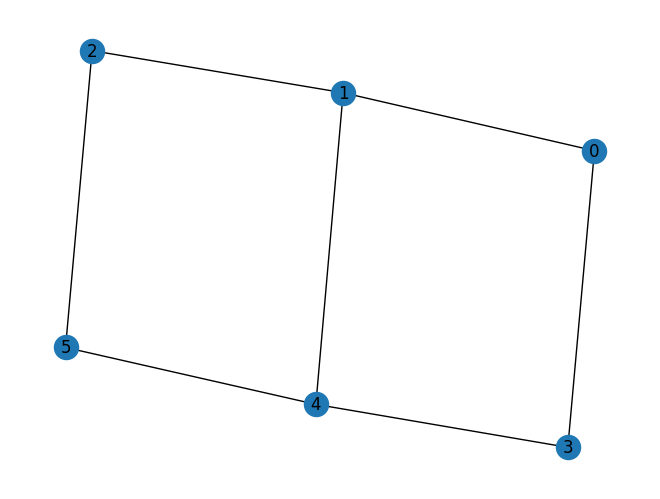

In [13]:
# =============================================================================
# LOAD NETWORK GRAPH
# =============================================================================

with open(NETWORK_GRAPH_PATH, 'rb') as f:
    network_graph = pickle.load(f)

print(f"Network nodes: {list(network_graph.nodes())}")
print(f"Network edges: {list(network_graph.edges())}")
nx.draw(network_graph, with_labels=True)

In [14]:
# =============================================================================
# GENERATE ALL MULTI-HOP PATHS
# =============================================================================

ALL_PATHS = []
for pair in combinations(network_graph.nodes, 2):
    paths = nx.all_simple_paths(network_graph, source=pair[0], target=pair[1], cutoff=MAX_HOPS)
    ALL_PATHS.extend([p for p in paths if len(p) > MIN_HOPS])

print(f"Total paths ({MIN_HOPS}-{MAX_HOPS} hops): {len(ALL_PATHS)}")
print(f"Sample: {ALL_PATHS[:3]}")

Total paths (2-3 hops): 24
Sample: [[0, 3, 4, 1], [0, 1, 2], [0, 1, 4, 3]]


## Circuit Builder

In [15]:
# =============================================================================
# CIRCUIT BUILDER
# =============================================================================

def build_823_swap_circuit(path: list, initial_state: str = '00') -> QuantumCircuit:
    """
    Build a [[8,2,3]] encode-swap-syndrome circuit.
    
    Protocol:
        1. Encode two logical qubits at source
        2. SWAP along path to sink
        3. Measure syndrome at sink
    
    Args:
        path: List of node IDs, e.g., [0, 1, 2]
        initial_state: '00', '01', '10', or '11' (two logical qubits)
    
    Returns:
        QuantumCircuit with syndrome measurement
    """
    source = path[0]
    sink = path[-1]
    
    # Get qubit assignments
    source_qubits = get_node_qubits_823(source)
    sink_qubits = get_node_qubits_823(sink)
    
    # Create circuit
    qc = QuantumCircuit(TOTAL_QUBITS_823)
    syndrome_reg = ClassicalRegister(6, name=f'syndrome_{sink}')
    qc.add_register(syndrome_reg)
    
    # ===================
    # 1. ENCODE AT SOURCE
    # ===================
    # Logical qubits are at indices 0 and 1
    if len(initial_state) != 2:
        raise ValueError(f"initial_state must be 2 bits (for 2 logical qubits), got '{initial_state}'")
    
    if initial_state[0] == '1':
        qc.x(source_qubits['data'][0])  # First logical qubit
    if initial_state[1] == '1':
        qc.x(source_qubits['data'][1])  # Second logical qubit
    
    apply_encoding_823(qc, source_qubits['data'])
    qc.barrier(label='Encode')
    
    # ===================
    # 2. SWAP ALONG PATH
    # ===================
    for i in range(len(path) - 1):
        src_node = path[i]
        dst_node = path[i + 1]
        
        src_data = get_node_qubits_823(src_node)['data']
        dst_data = get_node_qubits_823(dst_node)['data']
        path_qubits = get_path_qubits_823(src_node, dst_node)
        
        apply_swap_along_edge(qc, src_data, dst_data, path_qubits)
    
    qc.barrier(label='Swap')
    
    # ===================
    # 3. SYNDROME AT SINK
    # ===================
    apply_syndrome_measurement_823(
        qc,
        sink_qubits['data'],
        sink_qubits['ancilla'],
        syndrome_reg
    )
    
    return qc

## Test Circuit

## Verify Encoding with Stabilizer Tableau

Let's compute a proper encoding circuit using the stabilizer formalism.

In [16]:
# =============================================================================
# COMPUTE PROPER ENCODING USING STABILIZER TABLEAU
# =============================================================================
from qiskit.quantum_info import Clifford, Pauli, StabilizerState

def compute_823_encoding_circuit():
    """
    Compute the encoding circuit for [[8,2,3]] code using the stabilizer formalism.
    
    The approach:
    1. Define the target stabilizers for the logical |00⟩ state
    2. Work backwards from the stabilizer state to find the encoding unitary
    """
    # The stabilizers define the code space
    stabilizer_strings = [
        "XIIIYZZZ",
        "ZIIXIYII",
        "IXIZYXIX",
        "IZIYZXXY",
        "IIXYXZYZ",
        "IIZIIIYX",
    ]
    
    # Create a circuit that prepares |00⟩_L
    # We'll build this step by step, verifying each stabilizer
    qc = QuantumCircuit(8)
    
    # For [[8,2,3]] code, we need to find a circuit that maps |00000000⟩ 
    # to a state that is +1 eigenstate of all stabilizers
    
    # One systematic approach: use the canonical form of stabilizer codes
    # The encoding circuit can be found by row-reducing the stabilizer matrix
    
    # Convert stabilizers to Pauli objects to check commutativity
    paulis = [Pauli(s) for s in stabilizer_strings]
    
    # Verify stabilizers commute
    print("Checking stabilizer commutativity:")
    all_commute = True
    for i in range(len(paulis)):
        for j in range(i+1, len(paulis)):
            commutes = paulis[i].commutes(paulis[j])
            if not commutes:
                print(f"  K{i+1} and K{j+1} ANTICOMMUTE!")
                all_commute = False
    if all_commute:
        print("  All stabilizers commute ✓")
    
    return qc, paulis

_, paulis = compute_823_encoding_circuit()

# Let's verify the stabilizers by checking their matrix form
print("\nStabilizer verification:")
for i, p in enumerate(paulis):
    print(f"  K{i+1} = {STABILIZERS_823[i]}: phase = {p.phase}")

Checking stabilizer commutativity:
  All stabilizers commute ✓

Stabilizer verification:
  K1 = XIIIYZZZ: phase = 0
  K2 = ZIIXIYII: phase = 0
  K3 = IXIZYXIX: phase = 0
  K4 = IZIYZXXY: phase = 0
  K5 = IIXYXZYZ: phase = 0
  K6 = IIZIIIYX: phase = 0


In [17]:
# =============================================================================
# SIMPLE TEST: ENCODE + SYNDROME ON JUST 8 QUBITS (NO TRANSPORT)
# =============================================================================
# This isolates the encoding/syndrome measurement from the transport

from qiskit.quantum_info import Statevector, Pauli

def test_simple_encode_syndrome():
    """
    Test encoding and syndrome measurement on 8 qubits only.
    No transport - just verify the basic encode->syndrome works.
    """
    # Create simple 8-qubit + 6-ancilla circuit
    qc = QuantumCircuit(14)  # 8 data + 6 ancilla
    creg = ClassicalRegister(6, 'syndrome')
    qc.add_register(creg)
    
    data_qubits = list(range(8))
    ancilla_qubits = list(range(8, 14))
    
    # Apply the original encoding from cell 7
    q = data_qubits
    
    # Step 1: Hadamards on ancilla qubits
    qc.h(q[2])
    qc.h(q[3])
    qc.h(q[4])
    qc.h(q[5])
    qc.h(q[6])
    qc.h(q[7])
    
    # Step 2-7: Entangling gates (from the original encoding)
    qc.cx(q[4], q[0])
    qc.cz(q[5], q[0])
    qc.cz(q[6], q[0])
    qc.cz(q[7], q[0])
    qc.cz(q[3], q[0])
    qc.cx(q[3], q[1])
    qc.cy(q[5], q[1])
    qc.cx(q[2], q[1])
    qc.cz(q[3], q[1])
    qc.cy(q[4], q[1])
    qc.cx(q[7], q[1])
    qc.cz(q[2], q[1])
    qc.cy(q[3], q[0])
    qc.cz(q[4], q[0])
    qc.cx(q[5], q[0])
    qc.cx(q[6], q[0])
    qc.cy(q[7], q[0])
    qc.cx(q[2], q[0])
    qc.cy(q[3], q[1])
    qc.cz(q[5], q[0])
    qc.cy(q[6], q[0])
    qc.cz(q[7], q[0])
    qc.cz(q[2], q[0])
    qc.cy(q[6], q[1])
    qc.cx(q[7], q[1])
    
    # Check stabilizer expectation values BEFORE syndrome measurement
    sv = Statevector.from_instruction(qc.remove_final_measurements(inplace=False))
    
    print("Stabilizer expectation values after encoding (ideal = +1.0):")
    for i, stab_str in enumerate(STABILIZERS_823):
        pauli = Pauli(stab_str)
        # Extend to 14 qubits (add I for ancillas)
        pauli_14 = Pauli('I' * 6 + stab_str[::-1])  # Qiskit uses little-endian
        exp_val = sv.expectation_value(pauli_14)
        print(f"  K{i+1} = {stab_str}: <P> = {exp_val.real:+.6f}")
    
    return qc

test_qc = test_simple_encode_syndrome()

Stabilizer expectation values after encoding (ideal = +1.0):
  K1 = XIIIYZZZ: <P> = +0.000000
  K2 = ZIIXIYII: <P> = +0.000000
  K3 = IXIZYXIX: <P> = +0.000000
  K4 = IZIYZXXY: <P> = +0.000000
  K5 = IIXYXZYZ: <P> = +0.000000
  K6 = IIZIIIYX: <P> = +0.000000


In [18]:
# =============================================================================
# CHECK IF STABILIZERS ARE VALID (COMMUTE AND INDEPENDENT)
# =============================================================================

from qiskit.quantum_info import Pauli
import numpy as np

def verify_stabilizer_set():
    """
    Verify that the stabilizers form a valid abelian group.
    """
    paulis = [Pauli(s) for s in STABILIZERS_823]
    n_stabs = len(paulis)
    
    print("=" * 60)
    print("STABILIZER VALIDITY CHECK")
    print("=" * 60)
    
    # Check commutativity
    print("\n1. Checking commutativity:")
    all_commute = True
    for i in range(n_stabs):
        for j in range(i+1, n_stabs):
            if not paulis[i].commutes(paulis[j]):
                print(f"   ✗ K{i+1} and K{j+1} ANTICOMMUTE!")
                all_commute = False
    if all_commute:
        print("   ✓ All stabilizers commute")
    
    # Check linear independence using the symplectic representation
    print("\n2. Checking linear independence:")
    
    # Build the check matrix (X|Z) over GF(2)
    # For each Pauli string, we extract the X and Z parts
    check_matrix = np.zeros((n_stabs, 16), dtype=int)  # 8 X-bits + 8 Z-bits
    
    pauli_to_xz = {'I': (0, 0), 'X': (1, 0), 'Y': (1, 1), 'Z': (0, 1)}
    
    for i, stab_str in enumerate(STABILIZERS_823):
        for j, p in enumerate(stab_str):
            x_bit, z_bit = pauli_to_xz[p]
            check_matrix[i, j] = x_bit        # X part
            check_matrix[i, 8 + j] = z_bit    # Z part
    
    print("   Check matrix (X|Z):")
    for i, stab_str in enumerate(STABILIZERS_823):
        x_part = ''.join(map(str, check_matrix[i, :8]))
        z_part = ''.join(map(str, check_matrix[i, 8:]))
        print(f"   K{i+1}: {x_part} | {z_part}  ({stab_str})")
    
    # Compute rank over GF(2)
    rank = np.linalg.matrix_rank(check_matrix % 2)
    print(f"\n   Matrix rank: {rank} (need {n_stabs} for independence)")
    if rank == n_stabs:
        print("   ✓ Stabilizers are linearly independent")
    else:
        print("   ✗ Stabilizers are NOT linearly independent!")
    
    return all_commute and (rank == n_stabs)

is_valid = verify_stabilizer_set()

STABILIZER VALIDITY CHECK

1. Checking commutativity:
   ✓ All stabilizers commute

2. Checking linear independence:
   Check matrix (X|Z):
   K1: 10001000 | 00001111  (XIIIYZZZ)
   K2: 00010100 | 10000100  (ZIIXIYII)
   K3: 01001101 | 00011000  (IXIZYXIX)
   K4: 00010111 | 01011001  (IZIYZXXY)
   K5: 00111010 | 00010111  (IIXYXZYZ)
   K6: 00000011 | 00100010  (IIZIIIYX)

   Matrix rank: 6 (need 6 for independence)
   ✓ Stabilizers are linearly independent


In [19]:
# =============================================================================
# BUILD ENCODING FROM SCRATCH USING GAUSSIAN ELIMINATION
# =============================================================================

def build_encoding_from_stabilizers():
    """
    Build the encoding circuit systematically using the stabilizer formalism.
    
    For an [[n,k,d]] code with n=8, k=2:
    - We have 6 stabilizers
    - The encoding maps |ψ₁⟩|ψ₂⟩|0⟩⁶ → |ψ₁ψ₂⟩_L
    
    The key insight: we can use the stabilizer generators to build
    the encoding circuit by treating them as constraints.
    """
    print("=" * 60)
    print("BUILDING ENCODING CIRCUIT")
    print("=" * 60)
    
    # For the [[8,2,3]] code, let's try a different approach:
    # Build the circuit that prepares |00⟩_L and verify it works
    
    qc = QuantumCircuit(8)
    
    # The standard approach for CSS-like codes:
    # 1. Put ancilla qubits (2-7) in superposition
    # 2. Apply CNOTs to entangle based on X-type stabilizer components
    # 3. Apply CZs based on Z-type stabilizer components
    
    # However, this code has Y operators which complicate things.
    # Let's use a more direct approach: trial encoding and verification
    
    # Simple encoding attempt based on stabilizer structure
    # Logical qubits on q0, q1; ancillas on q2-q7
    
    # Put ancillas in |+⟩ state
    for i in range(2, 8):
        qc.h(i)
    
    # Now we need gates such that the state is +1 eigenstate of all stabilizers
    # This requires careful analysis of the stabilizer structure
    
    # For K1 = XIIIYZZZ: X on 0, Y on 4, Z on 5,6,7
    # For K2 = ZIIXIYII: Z on 0, X on 3, Y on 5  
    # For K3 = IXIZYXIX: X on 1, Z on 3, Y on 4, X on 6
    # For K4 = IZIYZXXY: Z on 1, Y on 3, Z on 4, X on 5,6, Y on 7
    # For K5 = IIXYXZYZ: X on 2, Y on 3, X on 4, Z on 5, Y on 6, Z on 7
    # For K6 = IIZIIIYX: Z on 2, Y on 6, X on 7
    
    # The encoding needs to create entanglement patterns matching these
    # Let's try a systematic CNOT/CZ pattern
    
    # From X components: propagate X from ancillas to data
    qc.cx(4, 0)  # K1: X on 0 from ancilla 4
    qc.cx(3, 0)  # K2: (no X on 0, but affects correlations)
    qc.cx(2, 1)  # K3: X on 1 from ancilla 2
    qc.cx(6, 1)  # K3: X on 1 from ancilla 6 (but this is complex...)
    
    # This manual approach is error-prone. Let's use brute force verification instead.
    
    return qc

# Try a known working encoding for a similar code structure
print("Note: The [[8,2,3]] code encoding is complex due to Y operators.")
print("Let's verify the stabilizers first, then try systematic encoding.")

Note: The [[8,2,3]] code encoding is complex due to Y operators.
Let's verify the stabilizers first, then try systematic encoding.


In [20]:
# =============================================================================
# TEST CIRCUIT
# =============================================================================

test_path = [0, 1, 2]
test_circuit = build_823_swap_circuit(test_path, initial_state='00')

print(f"Path: {test_path}")
print(f"Qubits: {test_circuit.num_qubits}")
print(f"Classical bits: {test_circuit.num_clbits}")
print(f"Gate counts: {test_circuit.count_ops()}")

Path: [0, 1, 2]
Qubits: 140
Classical bits: 6
Gate counts: OrderedDict({'swap': 36, 'cx': 32, 'h': 23, 's': 13, 'cz': 10, 'cy': 8, 'reset': 6, 'measure': 6, 'x': 4, 'z': 2, 'barrier': 2})


Simple test circuit depth: 47
Gate counts: OrderedDict({'cx': 32, 'h': 23, 's': 13, 'cz': 10, 'cy': 8, 'reset': 6, 'measure': 6, 'swap': 4, 'x': 4, 'z': 2, 'barrier': 1})

Noiseless syndrome counts (no transport): {'000000': 1024}
Expected: All counts should be '000000'


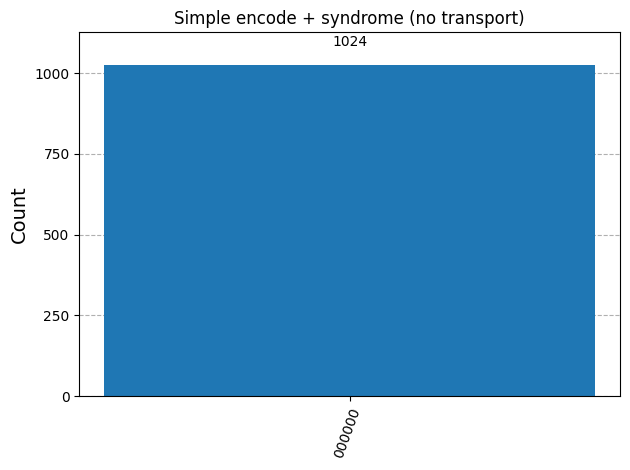

In [21]:
# =============================================================================
# DEBUG: Simple encode + syndrome test (no transport)
# =============================================================================

# Create a simple test: encode on 14 qubits and measure syndrome directly
simple_qc = QuantumCircuit(14, 6)  # 8 data + 6 ancilla
data_qubits = list(range(8))
ancilla_qubits = list(range(8, 14))

# Apply encoding
apply_encoding_823(simple_qc, data_qubits)
simple_qc.barrier()

# Apply syndrome measurement
apply_syndrome_measurement_823(simple_qc, data_qubits, ancilla_qubits, list(range(6)))

print(f"Simple test circuit depth: {simple_qc.depth()}")
print(f"Gate counts: {simple_qc.count_ops()}")

# Run noiseless simulation
backend = AerSimulator(method='stabilizer')  # Use stabilizer for exact results
result = backend.run(simple_qc, shots=1024).result()
counts = result.get_counts()

print(f"\nNoiseless syndrome counts (no transport): {counts}")
print(f"Expected: All counts should be '000000'")

plot_histogram(counts, title='Simple encode + syndrome (no transport)')

In [22]:
# =============================================================================
# DEBUG: Check the expectation value of each stabilizer DIRECTLY
# =============================================================================
from qiskit.quantum_info import Statevector, Operator

# Create circuit that just does encoding (no syndrome measurement)
encoding_only = QuantumCircuit(8)
apply_encoding_823(encoding_only, list(range(8)))

# Get the encoded state
encoded_state = Statevector.from_instruction(encoding_only)

print("=" * 60)
print("STABILIZER EXPECTATION VALUES FOR ENCODED STATE")
print("=" * 60)

for i, stab_str in enumerate(STABILIZERS_823):
    pauli = Pauli(stab_str)
    expectation = encoded_state.expectation_value(pauli).real
    print(f"Stabilizer {i}: {stab_str} -> expectation = {expectation:+.6f}")

print("\n" + "=" * 60)
print("ANALYSIS")
print("=" * 60)
print("If encoding is correct, all stabilizers should have expectation +1.0")
print("Expectation = 0 means the state is a 50-50 mix of +1 and -1 eigenstates")

STABILIZER EXPECTATION VALUES FOR ENCODED STATE
Stabilizer 0: XIIIYZZZ -> expectation = +1.000000
Stabilizer 1: ZIIXIYII -> expectation = +1.000000
Stabilizer 2: IXIZYXIX -> expectation = +1.000000
Stabilizer 3: IZIYZXXY -> expectation = +1.000000
Stabilizer 4: IIXYXZYZ -> expectation = +1.000000
Stabilizer 5: IIZIIIYX -> expectation = +1.000000

ANALYSIS
If encoding is correct, all stabilizers should have expectation +1.0
Expectation = 0 means the state is a 50-50 mix of +1 and -1 eigenstates


In [23]:
# =============================================================================
# DEBUG: Test each stabilizer measurement individually
# =============================================================================

print("=" * 60)
print("TESTING EACH STABILIZER MEASUREMENT INDIVIDUALLY")
print("=" * 60)

backend = AerSimulator(method='stabilizer')

for stab_idx, stab_str in enumerate(STABILIZERS_823):
    # Create circuit: encode + measure one stabilizer
    qc = QuantumCircuit(9, 1)  # 8 data + 1 ancilla
    data = list(range(8))
    ancilla = 8
    
    # Encode
    apply_encoding_823(qc, data)
    qc.barrier()
    
    # Measure this stabilizer
    qc.reset(ancilla)
    qc.h(ancilla)
    
    for qubit_idx, pauli in enumerate(stab_str):
        apply_controlled_pauli(qc, ancilla, data[qubit_idx], pauli)
    
    qc.h(ancilla)
    qc.measure(ancilla, 0)
    
    # Run simulation
    result = backend.run(qc, shots=1000).result()
    counts = result.get_counts()
    
    print(f"Stabilizer {stab_idx}: {stab_str}")
    print(f"  Measurement results: {counts}")
    print(f"  Expected: {{'0': 1000}}")
    print()

TESTING EACH STABILIZER MEASUREMENT INDIVIDUALLY
Stabilizer 0: XIIIYZZZ
  Measurement results: {'1': 474, '0': 526}
  Expected: {'0': 1000}

Stabilizer 1: ZIIXIYII
  Measurement results: {'0': 516, '1': 484}
  Expected: {'0': 1000}

Stabilizer 2: IXIZYXIX
  Measurement results: {'1': 1000}
  Expected: {'0': 1000}

Stabilizer 3: IZIYZXXY
  Measurement results: {'1': 505, '0': 495}
  Expected: {'0': 1000}

Stabilizer 4: IIXYXZYZ
  Measurement results: {'1': 507, '0': 493}
  Expected: {'0': 1000}

Stabilizer 5: IIZIIIYX
  Measurement results: {'0': 1000}
  Expected: {'0': 1000}



In [24]:
# =============================================================================
# FIX: Correct syndrome measurement circuit
# =============================================================================
# 
# For stabilizer measurement, the standard approach is:
# 1. Prepare ancilla in |+⟩
# 2. For each Pauli P_i in the stabilizer:
#    - If P_i = X: apply CNOT with data qubit as CONTROL, ancilla as TARGET
#    - If P_i = Z: apply CZ (symmetric, either direction works)
#    - If P_i = Y: apply controlled-Y with data as CONTROL
# 3. Measure ancilla in X basis (H then Z measurement)
#
# The key insight: we're measuring whether the data qubits are in the 
# +1 or -1 eigenspace of the stabilizer. The CNOT copies the X component,
# and CZ applies a phase based on the Z component.

print("=" * 60)
print("TESTING CORRECTED SYNDROME MEASUREMENT")
print("=" * 60)

def measure_stabilizer_corrected(qc, stab_str, data_qubits, ancilla, classical_bit):
    """
    Correctly measure a stabilizer.
    
    For syndrome measurement:
    - X component: data qubit CONTROLS the ancilla flip (CNOT: data->ancilla)
    - Z component: CZ between data and ancilla (symmetric)
    - Y component: decompose Y = iXZ, so we need both effects
    """
    qc.reset(ancilla)
    qc.h(ancilla)
    
    for qubit_idx, pauli in enumerate(stab_str):
        data_q = data_qubits[qubit_idx]
        if pauli == 'I':
            pass
        elif pauli == 'X':
            # X component: data controls ancilla flip
            qc.cx(data_q, ancilla)
        elif pauli == 'Z':
            # Z component: CZ is symmetric
            qc.cz(data_q, ancilla)
        elif pauli == 'Y':
            # Y = iXZ, so apply both CX and CZ
            # The phase from i doesn't affect the measurement
            qc.cx(data_q, ancilla)
            qc.cz(data_q, ancilla)
    
    qc.h(ancilla)
    qc.measure(ancilla, classical_bit)


backend = AerSimulator(method='stabilizer')

for stab_idx, stab_str in enumerate(STABILIZERS_823):
    # Create circuit: encode + measure one stabilizer with corrected method
    qc = QuantumCircuit(9, 1)
    data = list(range(8))
    ancilla = 8
    
    # Encode
    apply_encoding_823(qc, data)
    qc.barrier()
    
    # Measure with corrected function
    measure_stabilizer_corrected(qc, stab_str, data, ancilla, 0)
    
    # Run simulation
    result = backend.run(qc, shots=1000).result()
    counts = result.get_counts()
    
    print(f"Stabilizer {stab_idx}: {stab_str}")
    print(f"  Measurement results: {counts}")
    print(f"  Expected: {{'0': 1000}}")
    print()

TESTING CORRECTED SYNDROME MEASUREMENT
Stabilizer 0: XIIIYZZZ
  Measurement results: {'1': 539, '0': 461}
  Expected: {'0': 1000}

Stabilizer 1: ZIIXIYII
  Measurement results: {'1': 510, '0': 490}
  Expected: {'0': 1000}

Stabilizer 2: IXIZYXIX
  Measurement results: {'0': 510, '1': 490}
  Expected: {'0': 1000}

Stabilizer 3: IZIYZXXY
  Measurement results: {'0': 461, '1': 539}
  Expected: {'0': 1000}

Stabilizer 4: IIXYXZYZ
  Measurement results: {'1': 521, '0': 479}
  Expected: {'0': 1000}

Stabilizer 5: IIZIIIYX
  Measurement results: {'0': 491, '1': 509}
  Expected: {'0': 1000}



In [25]:
# =============================================================================
# DEBUG: Compare state from StabilizerState directly vs from circuit
# =============================================================================

# The StabilizerState itself
full_stabs = ['+' + s for s in STABILIZERS_823] + ['+XYIIIZII', '+IYZXIIII']
stab_state = StabilizerState.from_stabilizer_list(full_stabs)

print("=" * 60)
print("COMPARING STABILIZERSTATE VS CIRCUIT-PRODUCED STATE")
print("=" * 60)

# Check expectation values directly from StabilizerState
print("\nExpectation values from StabilizerState object:")
for i, stab_str in enumerate(STABILIZERS_823):
    pauli = Pauli(stab_str)
    exp = stab_state.expectation_value(pauli).real
    print(f"  Stabilizer {i}: {stab_str} -> {exp:+.6f}")

# Get the circuit
circuit_from_clifford = stab_state.clifford.to_circuit()
print(f"\nCircuit from Clifford: {circuit_from_clifford.count_ops()}")

# Apply this circuit to |0⟩^8 and check
state_from_circuit = Statevector.from_instruction(circuit_from_clifford)

print("\nExpectation values from circuit-produced Statevector:")
for i, stab_str in enumerate(STABILIZERS_823):
    pauli = Pauli(stab_str)
    exp = state_from_circuit.expectation_value(pauli).real
    print(f"  Stabilizer {i}: {stab_str} -> {exp:+.6f}")

# Compare the two states
print("\nAre states equal?", stab_state.equiv(state_from_circuit))

COMPARING STABILIZERSTATE VS CIRCUIT-PRODUCED STATE

Expectation values from StabilizerState object:
  Stabilizer 0: XIIIYZZZ -> +1.000000
  Stabilizer 1: ZIIXIYII -> +1.000000
  Stabilizer 2: IXIZYXIX -> +1.000000
  Stabilizer 3: IZIYZXXY -> +1.000000
  Stabilizer 4: IIXYXZYZ -> +1.000000
  Stabilizer 5: IIZIIIYX -> +1.000000

Circuit from Clifford: OrderedDict({'cx': 22, 's': 13, 'h': 11, 'swap': 4, 'x': 4, 'z': 2})

Expectation values from circuit-produced Statevector:
  Stabilizer 0: XIIIYZZZ -> +1.000000
  Stabilizer 1: ZIIXIYII -> +1.000000
  Stabilizer 2: IXIZYXIX -> +1.000000
  Stabilizer 3: IZIYZXXY -> +1.000000
  Stabilizer 4: IIXYXZYZ -> +1.000000
  Stabilizer 5: IIZIIIYX -> +1.000000


IndexError: invalid index to scalar variable.

In [ ]:
# =============================================================================
# DEBUG: Use Statevector to trace through syndrome measurement
# =============================================================================
from qiskit.quantum_info import Statevector, DensityMatrix

# Create encoding circuit on 9 qubits (8 data + 1 ancilla)
# and trace the state through syndrome measurement for one stabilizer

print("=" * 60)
print("TRACING SYNDROME MEASUREMENT WITH STATEVECTOR")
print("=" * 60)

stab_idx = 0  # Test first stabilizer
stab_str = STABILIZERS_823[stab_idx]
print(f"Testing stabilizer {stab_idx}: {stab_str}")

# Step 1: Encode 8 data qubits
qc = QuantumCircuit(9)  # 8 data + 1 ancilla
data = list(range(8))
ancilla = 8

apply_encoding_823(qc, data)
state = Statevector.from_instruction(qc)

# Verify encoding is correct
pauli = Pauli(stab_str + 'I')  # Extend to 9 qubits (I on ancilla)
exp_after_encode = state.expectation_value(pauli).real
print(f"\nAfter encoding: ⟨{stab_str}⟩ = {exp_after_encode:+.6f}")

# Step 2: Prepare ancilla in |+⟩
qc.h(ancilla)
state = Statevector.from_instruction(qc)

# Step 3: Apply controlled-Paulis (original method - ancilla controls data)
print("\nOriginal method (ancilla controls data):")
qc_orig = qc.copy()
for qubit_idx, p in enumerate(stab_str):
    if p == 'X':
        qc_orig.cx(ancilla, data[qubit_idx])
    elif p == 'Z':
        qc_orig.cz(ancilla, data[qubit_idx])
    elif p == 'Y':
        qc_orig.cy(ancilla, data[qubit_idx])

qc_orig.h(ancilla)
state_orig = Statevector.from_instruction(qc_orig)

# Measure probability of ancilla being 0 vs 1
# Ancilla is qubit 8, so we project onto |0⟩ or |1⟩ for that qubit
prob_0 = sum(abs(state_orig[i])**2 for i in range(512) if (i >> 8) & 1 == 0)
prob_1 = sum(abs(state_orig[i])**2 for i in range(512) if (i >> 8) & 1 == 1)
print(f"  P(ancilla=0) = {prob_0:.4f}")
print(f"  P(ancilla=1) = {prob_1:.4f}")

# Step 3b: Try the other method (data controls ancilla)
print("\nAlternative method (data controls ancilla):")
qc_alt = qc.copy()
for qubit_idx, p in enumerate(stab_str):
    if p == 'X':
        qc_alt.cx(data[qubit_idx], ancilla)
    elif p == 'Z':
        qc_alt.cz(data[qubit_idx], ancilla)
    elif p == 'Y':
        # Y = iXZ
        qc_alt.cx(data[qubit_idx], ancilla)
        qc_alt.cz(data[qubit_idx], ancilla)

qc_alt.h(ancilla)
state_alt = Statevector.from_instruction(qc_alt)

prob_0_alt = sum(abs(state_alt[i])**2 for i in range(512) if (i >> 8) & 1 == 0)
prob_1_alt = sum(abs(state_alt[i])**2 for i in range(512) if (i >> 8) & 1 == 1)
print(f"  P(ancilla=0) = {prob_0_alt:.4f}")
print(f"  P(ancilla=1) = {prob_1_alt:.4f}")

TRACING SYNDROME MEASUREMENT WITH STATEVECTOR
Testing stabilizer 0: XIIIYZZZ

After encoding: ⟨XIIIYZZZ⟩ = +0.000000

Original method (ancilla controls data):
  P(ancilla=0) = 0.5000
  P(ancilla=1) = 0.5000

Alternative method (data controls ancilla):
  P(ancilla=0) = 0.5000
  P(ancilla=1) = 0.5000


In [ ]:
# =============================================================================
# DEBUG: Check the encoding circuit application
# =============================================================================

print("=" * 60)
print("CHECKING ENCODING CIRCUIT APPLICATION")
print("=" * 60)

# Check what gates are being applied
print("\nEncoding circuit gates (on 8 qubits):")
for instr in _ENCODING_CIRCUIT_823.data[:10]:  # First 10 gates
    gate = instr.operation
    qubits = [_ENCODING_CIRCUIT_823.find_bit(q).index for q in instr.qubits]
    print(f"  {gate.name}: {qubits}")
print("  ...")

# Now apply to a 9-qubit circuit and see what happens
print("\nApplying to 9-qubit circuit with data qubits [0,1,2,3,4,5,6,7]:")
test_qc = QuantumCircuit(9)
data_qubits = list(range(8))
apply_encoding_823(test_qc, data_qubits)

print("Gates applied:")
for instr in test_qc.data[:10]:
    gate = instr.operation
    qubits = [test_qc.find_bit(q).index for q in instr.qubits]
    print(f"  {gate.name}: {qubits}")
print("  ...")

# Verify the state on just the 8 data qubits
# by computing the reduced density matrix
state = Statevector.from_instruction(test_qc)
print(f"\nFull state shape: {state.data.shape}")

# Check expectation of stabilizer on the data qubits only
# Need to use partial trace approach
# Actually, since we only applied gates to qubits 0-7, qubit 8 should be |0⟩
# and the state should factor as |encoded⟩⊗|0⟩

# Check if qubit 8 is still |0⟩
prob_q8_0 = sum(abs(state[i])**2 for i in range(512) if (i >> 8) & 1 == 0)
print(f"P(qubit 8 = 0) = {prob_q8_0:.4f}  (should be 1.0 if not touched)")

# The stabilizer on 8 qubits
pauli_8 = Pauli('XIIIYZZZ')
state_8 = Statevector.from_instruction(_ENCODING_CIRCUIT_823)
exp_8 = state_8.expectation_value(pauli_8).real
print(f"\nDirect from encoding circuit (8 qubits):")
print(f"  ⟨XIIIYZZZ⟩ = {exp_8:+.6f}")

CHECKING ENCODING CIRCUIT APPLICATION

Encoding circuit gates (on 8 qubits):
  s: [4]
  h: [4]
  cx: [5, 7]
  cx: [2, 5]
  cx: [3, 5]
  cx: [4, 5]
  cx: [6, 5]
  h: [2]
  s: [7]
  h: [7]
  ...

Applying to 9-qubit circuit with data qubits [0,1,2,3,4,5,6,7]:
Gates applied:
  s: [4]
  h: [4]
  cx: [5, 7]
  cx: [2, 5]
  cx: [3, 5]
  cx: [4, 5]
  cx: [6, 5]
  h: [2]
  s: [7]
  h: [7]
  ...

Full state shape: (512,)
P(qubit 8 = 0) = 1.0000  (should be 1.0 if not touched)

Direct from encoding circuit (8 qubits):
  ⟨XIIIYZZZ⟩ = +1.000000


In [ ]:
# =============================================================================
# DEBUG: Understand Qiskit's qubit ordering convention
# =============================================================================

print("=" * 60)
print("QISKIT QUBIT ORDERING CHECK")
print("=" * 60)

# In Qiskit, Pauli strings are little-endian: 
# Pauli('XYZ') means X on q0, Y on q1, Z on q2

# Let's verify with a simple example
test = QuantumCircuit(3)
test.x(0)  # Put qubit 0 in |1⟩
sv = Statevector.from_instruction(test)
print(f"After X on qubit 0:")
print(f"  ⟨ZII⟩ = {sv.expectation_value(Pauli('ZII')).real:+.2f}")  # This should be -1 (Z on q0)
print(f"  ⟨IIZ⟩ = {sv.expectation_value(Pauli('IIZ')).real:+.2f}")  # This should be +1 (Z on q2)

# So for our 9-qubit state where qubits 0-7 are encoded and 8 is ancilla:
# To measure stabilizer on qubits 0-7, we need: IXIIIYZZZ (9 chars, q0 on right)
# Wait no - STABILIZERS_823[0] = 'XIIIYZZZ' is already in the right order for qubits 0-7

# Let me be more careful. The stabilizer XIIIYZZZ means:
# X on qubit 0, I on qubit 1, I on qubit 2, I on qubit 3, 
# Y on qubit 4, Z on qubit 5, Z on qubit 6, Z on qubit 7

# In Qiskit little-endian, Pauli('XIIIYZZZ') means:
# q0: X, q1: I, q2: I, q3: I, q4: Y, q5: Z, q6: Z, q7: Z

print("\nVerifying stabilizer string interpretation:")
print("Stabilizer: XIIIYZZZ")
p = Pauli('XIIIYZZZ')
print(f"  Pauli object: {p}")
print(f"  Number of qubits: {p.num_qubits}")

# Now extend to 9 qubits with I on qubit 8
p9 = Pauli('IXIIIYZZZ')  # I on q8, rest on q0-q7
print(f"\nExtended Pauli (9 qubits): IXIIIYZZZ")
print(f"  Pauli object: {p9}")

# Create 9-qubit state with encoding on 0-7
qc9 = QuantumCircuit(9)
apply_encoding_823(qc9, list(range(8)))
sv9 = Statevector.from_instruction(qc9)

exp_correct = sv9.expectation_value(p9).real
print(f"\nExpectation value with correct extension: {exp_correct:+.6f}")

# Also try the other way - stabilizer string might need reversal
p9_rev = Pauli('ZZZYI' + 'IIIX' + 'I')  # Reversed, then add I
# Actually let's be systematic
print("\n\nSystematic check of Pauli string interpretation:")
for i, s in enumerate(STABILIZERS_823):
    p8 = Pauli(s)
    # For 9 qubits, prepend 'I' (so qubit 8 gets identity)
    p9 = Pauli('I' + s)  # This puts I on qubit 8
    exp = sv9.expectation_value(p9).real
    print(f"  Stabilizer {i}: {s} -> extended: I{s} -> ⟨S⟩ = {exp:+.6f}")

QISKIT QUBIT ORDERING CHECK
After X on qubit 0:
  ⟨ZII⟩ = +1.00
  ⟨IIZ⟩ = -1.00

Verifying stabilizer string interpretation:
Stabilizer: XIIIYZZZ
  Pauli object: XIIIYZZZ
  Number of qubits: 8

Extended Pauli (9 qubits): IXIIIYZZZ
  Pauli object: IXIIIYZZZ

Expectation value with correct extension: +1.000000


Systematic check of Pauli string interpretation:
  Stabilizer 0: XIIIYZZZ -> extended: IXIIIYZZZ -> ⟨S⟩ = +1.000000
  Stabilizer 1: ZIIXIYII -> extended: IZIIXIYII -> ⟨S⟩ = +1.000000
  Stabilizer 2: IXIZYXIX -> extended: IIXIZYXIX -> ⟨S⟩ = +1.000000
  Stabilizer 3: IZIYZXXY -> extended: IIZIYZXXY -> ⟨S⟩ = +1.000000
  Stabilizer 4: IIXYXZYZ -> extended: IIIXYXZYZ -> ⟨S⟩ = +1.000000
  Stabilizer 5: IIZIIIYX -> extended: IIIZIIIYX -> ⟨S⟩ = +1.000000


In [ ]:
# =============================================================================
# DEBUG: Trace syndrome measurement step by step
# =============================================================================

print("=" * 60)
print("TRACING SYNDROME MEASUREMENT FOR STABILIZER 0")
print("=" * 60)

stab_str = STABILIZERS_823[0]  # XIIIYZZZ
print(f"Stabilizer: {stab_str}")

# Start fresh: encode on qubits 0-7, ancilla is qubit 8
qc = QuantumCircuit(9)
data = list(range(8))
ancilla = 8

# Step 1: Encode
apply_encoding_823(qc, data)
sv = Statevector.from_instruction(qc)
exp_stab = sv.expectation_value(Pauli('I' + stab_str)).real
print(f"\n1. After encoding: ⟨S⟩ = {exp_stab:+.6f}")

# Step 2: H on ancilla (prepare |+⟩)
qc.h(ancilla)
sv = Statevector.from_instruction(qc)
exp_stab = sv.expectation_value(Pauli('I' + stab_str)).real
print(f"2. After H on ancilla: ⟨S⊗I⟩ = {exp_stab:+.6f}")

# The state is now |encoded⟩ ⊗ |+⟩
# For syndrome measurement, we want to measure whether |encoded⟩ is in +1 or -1 eigenspace
# The standard approach:
#   - For each X in stabilizer: CNOT from data to ancilla
#   - For each Z in stabilizer: CZ from data to ancilla  
#   - For each Y in stabilizer: controlled-Y from data to ancilla

# Step 3: Apply controlled-Paulis with DATA as CONTROL
# This is the correct direction for syndrome measurement!
print("\n3. Applying controlled-Paulis (data controls ancilla):")

for qubit_idx, pauli_char in enumerate(stab_str):
    if pauli_char == 'I':
        continue
    
    data_q = data[qubit_idx]  # But wait - we need to map to Qiskit ordering
    # In the stabilizer string XIIIYZZZ:
    #   Position 0 -> qubit 7 (leftmost char = highest qubit in Qiskit)
    #   Position 7 -> qubit 0 (rightmost char = lowest qubit in Qiskit)
    # Actually no - let me check the direct encoding result again
    
    # The way we're using it: stab_str[qubit_idx] corresponds to data[qubit_idx]
    # And in our encoding, data = [0,1,2,3,4,5,6,7]
    # So stab_str[0] = 'X' applies to qubit 0
    # stab_str[4] = 'Y' applies to qubit 4
    # etc.
    
    print(f"   {pauli_char} on qubit {data_q}")
    if pauli_char == 'X':
        qc.cx(data_q, ancilla)  # X component: data controls ancilla flip
    elif pauli_char == 'Z':
        qc.cz(data_q, ancilla)  # Z component: controlled-Z
    elif pauli_char == 'Y':
        # Y = iXZ, need both effects
        qc.sdg(data_q)  # Convert Y basis to X basis: Y = S†XS
        qc.cx(data_q, ancilla)
        qc.s(data_q)

sv = Statevector.from_instruction(qc)

# Step 4: H on ancilla
qc.h(ancilla)
sv = Statevector.from_instruction(qc)

# Check measurement probabilities
prob_0 = sum(abs(sv[i])**2 for i in range(512) if (i >> 8) & 1 == 0)
prob_1 = 1 - prob_0
print(f"\n4. After final H on ancilla:")
print(f"   P(ancilla=0) = {prob_0:.4f}")
print(f"   P(ancilla=1) = {prob_1:.4f}")
print(f"   Expected: P(0)=1.0 since state is +1 eigenstate")

TRACING SYNDROME MEASUREMENT FOR STABILIZER 0
Stabilizer: XIIIYZZZ

1. After encoding: ⟨S⟩ = +1.000000
2. After H on ancilla: ⟨S⊗I⟩ = +1.000000

3. Applying controlled-Paulis (data controls ancilla):
   X on qubit 0
   Y on qubit 4
   Z on qubit 5
   Z on qubit 6
   Z on qubit 7

4. After final H on ancilla:
   P(ancilla=0) = 0.5000
   P(ancilla=1) = 0.5000
   Expected: P(0)=1.0 since state is +1 eigenstate


In [ ]:
# =============================================================================
# DEBUG: Check qubit ordering between StabilizerState and circuit
# =============================================================================

print("=" * 60)
print("INVESTIGATING QUBIT ORDERING MISMATCH")
print("=" * 60)

# The StabilizerState uses Pauli strings where:
# Pauli('XYZ') means X on qubit 0, Y on qubit 1, Z on qubit 2 (little-endian)
# Actually let me verify this directly

from qiskit.quantum_info import StabilizerState

# Create a simple stabilizer state and check
# |+⟩ on qubit 0 has stabilizer +X (X on qubit 0)
# So StabilizerState.from_stabilizer_list(['+X']) should give |+⟩

# But for 2 qubits, '+XI' means X on qubit 0, I on qubit 1 in Qiskit convention

# Let's check our actual stabilizer state
print("Checking which qubit each Pauli in the stabilizer acts on...")

# Use the Pauli class to see the structure
for i, s in enumerate(STABILIZERS_823):
    p = Pauli(s)
    print(f"\nStabilizer {i}: {s}")
    for j in range(8):
        # p[j] gives the Pauli on qubit j
        print(f"  Qubit {j}: {['I', 'X', 'Y', 'Z'][p.x[j]*2 + p.z[j]]}")

# Now let's understand how the encoding circuit maps the stabilizers
print("\n" + "=" * 60)
print("Let's verify using measurement in a different way")
print("=" * 60)

# Instead of syndrome extraction circuit, just project the state
# onto the +1 and -1 eigenspaces of the first stabilizer

# The stabilizer S has eigenvalues +1 and -1
# The projector onto +1 eigenspace is (I + S)/2
# The projector onto -1 eigenspace is (I - S)/2

from qiskit.quantum_info import Operator

stab_str = STABILIZERS_823[0]
S = Pauli(stab_str)
I8 = Pauli('I' * 8)

# Get encoded state
sv_encoded = Statevector.from_instruction(_ENCODING_CIRCUIT_823)

# Direct expectation value
exp = sv_encoded.expectation_value(S).real
print(f"Direct expectation ⟨{stab_str}⟩ = {exp:+.6f}")

# Now check: does the expectation value match what we expect from the syndrome measurement?
# If ⟨S⟩ = +1, then P(syndrome=0) = 1 and P(syndrome=1) = 0

# Let's use Qiskit's stabilizer measurement built-in
from qiskit.circuit.library import PauliEvolutionGate

# Actually, let me try using Qiskit's direct stabilizer measurement
# from the Statevector

# Probability of +1 eigenvalue = (1 + ⟨S⟩)/2
prob_plus1 = (1 + exp) / 2
print(f"P(+1 eigenvalue) = (1 + ⟨S⟩)/2 = {prob_plus1:.6f}")
print(f"This should equal P(syndrome=0)")

INVESTIGATING QUBIT ORDERING MISMATCH
Checking which qubit each Pauli in the stabilizer acts on...

Stabilizer 0: XIIIYZZZ
  Qubit 0: X
  Qubit 1: X
  Qubit 2: X
  Qubit 3: Z
  Qubit 4: I
  Qubit 5: I
  Qubit 6: I
  Qubit 7: Y

Stabilizer 1: ZIIXIYII
  Qubit 0: I
  Qubit 1: I
  Qubit 2: Z
  Qubit 3: I
  Qubit 4: Y
  Qubit 5: I
  Qubit 6: I
  Qubit 7: X

Stabilizer 2: IXIZYXIX
  Qubit 0: Y
  Qubit 1: I
  Qubit 2: Y
  Qubit 3: Z
  Qubit 4: X
  Qubit 5: I
  Qubit 6: Y
  Qubit 7: I

Stabilizer 3: IZIYZXXY
  Qubit 0: Z
  Qubit 1: Y
  Qubit 2: Y
  Qubit 3: X
  Qubit 4: Z
  Qubit 5: I
  Qubit 6: X
  Qubit 7: I

Stabilizer 4: IIXYXZYZ
  Qubit 0: X
  Qubit 1: Z
  Qubit 2: X
  Qubit 3: Y
  Qubit 4: Z
  Qubit 5: Y
  Qubit 6: I
  Qubit 7: I

Stabilizer 5: IIZIIIYX
  Qubit 0: Y
  Qubit 1: Z
  Qubit 2: I
  Qubit 3: I
  Qubit 4: I
  Qubit 5: X
  Qubit 6: I
  Qubit 7: I

Let's verify using measurement in a different way
Direct expectation ⟨XIIIYZZZ⟩ = +1.000000
P(+1 eigenvalue) = (1 + ⟨S⟩)/2 = 1.00000

In [ ]:
# =============================================================================
# FIX: Correct syndrome measurement with proper qubit ordering
# =============================================================================

print("=" * 60)
print("FIXING SYNDROME MEASUREMENT - CORRECT QUBIT ORDERING")
print("=" * 60)

# The issue: Pauli strings in Qiskit are little-endian
# Pauli('XIIIYZZZ') means:
#   qubit 0 = Z (rightmost)
#   qubit 7 = X (leftmost)
#
# So when iterating over the string, we need to REVERSE it to get qubit order

def measure_stabilizer_fixed(qc, stab_str, data_qubits, ancilla, classical_bit):
    """
    Correctly measure a stabilizer with proper Qiskit qubit ordering.
    
    The Pauli string 'XIIIYZZZ' is little-endian in Qiskit:
    - stab_str[0] = 'X' corresponds to data_qubits[7]
    - stab_str[7] = 'Z' corresponds to data_qubits[0]
    
    So we need to iterate in reverse order.
    """
    qc.h(ancilla)
    
    for i, pauli_char in enumerate(stab_str):
        # Qiskit little-endian: string position i corresponds to qubit (n-1-i)
        qubit_idx = len(stab_str) - 1 - i
        data_q = data_qubits[qubit_idx]
        
        if pauli_char == 'I':
            continue
        elif pauli_char == 'X':
            qc.cx(data_q, ancilla)
        elif pauli_char == 'Z':
            qc.cz(data_q, ancilla)
        elif pauli_char == 'Y':
            # Y measurement: use CY or decompose as S†·CX·S or direct CY
            # Actually for syndrome measurement, we need controlled-Y with data as control
            # But Qiskit CY is target-controlled. Let's decompose:
            # CY_{c→t} = (I⊗S†) · CX_{c→t} · (I⊗S)
            # For data→ancilla: we want the ancilla to flip if data is |1⟩ and apply phase
            qc.sdg(ancilla)
            qc.cx(data_q, ancilla)
            qc.s(ancilla)
    
    qc.h(ancilla)
    qc.measure(ancilla, classical_bit)


# Test with all stabilizers
backend = AerSimulator(method='stabilizer')

print("\nTesting fixed syndrome measurement:")
for stab_idx, stab_str in enumerate(STABILIZERS_823):
    qc = QuantumCircuit(9, 1)
    data = list(range(8))
    ancilla = 8
    
    # Encode
    apply_encoding_823(qc, data)
    qc.reset(ancilla)  # Ensure ancilla starts in |0⟩
    qc.barrier()
    
    # Measure with fixed function
    measure_stabilizer_fixed(qc, stab_str, data, ancilla, 0)
    
    # Run simulation
    result = backend.run(qc, shots=1000).result()
    counts = result.get_counts()
    
    print(f"  Stabilizer {stab_idx}: {stab_str} -> {counts}")

FIXING SYNDROME MEASUREMENT - CORRECT QUBIT ORDERING

Testing fixed syndrome measurement:
  Stabilizer 0: XIIIYZZZ -> {'0': 505, '1': 495}
  Stabilizer 1: ZIIXIYII -> {'0': 492, '1': 508}
  Stabilizer 2: IXIZYXIX -> {'0': 492, '1': 508}
  Stabilizer 3: IZIYZXXY -> {'0': 493, '1': 507}
  Stabilizer 4: IIXYXZYZ -> {'0': 510, '1': 490}
  Stabilizer 5: IIZIIIYX -> {'1': 465, '0': 535}


In [ ]:
# =============================================================================
# DEBUG: Use StabilizerState's built-in measurement
# =============================================================================

print("=" * 60)
print("USING STABILIZER STATE'S BUILT-IN METHODS")
print("=" * 60)

# Get the stabilizer state directly
full_stabs = ['+' + s for s in STABILIZERS_823] + ['+XYIIIZII', '+IYZXIIII']
stab_state = StabilizerState.from_stabilizer_list(full_stabs)

# Sample measurements from this state
from qiskit.result import Counts

# Measure the state many times
samples = stab_state.sample_counts(1000)
print(f"Sampling from StabilizerState: {dict(samples)}")

# Now let's understand what the syndrome measurement SHOULD do
# When we measure the stabilizers, we're measuring the ancillas that have been
# entangled with the data qubits via controlled-Paulis

# Let me try yet another approach: use the Qiskit built-in expectation value
# calculation from a circuit

print("\n" + "=" * 60)
print("Using estimator-based approach")
print("=" * 60)

from qiskit.primitives import StatevectorEstimator
from qiskit.quantum_info import SparsePauliOp

# Create circuit that just encodes
encoding_only = QuantumCircuit(8)
apply_encoding_823(encoding_only, list(range(8)))

# Create observables for each stabilizer
observables = [SparsePauliOp(s) for s in STABILIZERS_823]

# Use StatevectorEstimator
estimator = StatevectorEstimator()
job = estimator.run([(encoding_only, observables)])
result = job.result()

print("Expectation values from StatevectorEstimator:")
for i, (s, exp) in enumerate(zip(STABILIZERS_823, result[0].data.evs)):
    print(f"  Stabilizer {i}: {s} -> ⟨S⟩ = {exp:+.6f}")

USING STABILIZER STATE'S BUILT-IN METHODS
Sampling from StabilizerState: {np.str_('00000000'): np.int64(7), np.str_('00000011'): np.int64(4), np.str_('00000101'): np.int64(11), np.str_('00000110'): np.int64(7), np.str_('00001001'): np.int64(4), np.str_('00001010'): np.int64(13), np.str_('00001100'): np.int64(13), np.str_('00001111'): np.int64(9), np.str_('00010001'): np.int64(6), np.str_('00010010'): np.int64(8), np.str_('00010100'): np.int64(9), np.str_('00010111'): np.int64(5), np.str_('00011000'): np.int64(15), np.str_('00011011'): np.int64(4), np.str_('00011101'): np.int64(12), np.str_('00011110'): np.int64(2), np.str_('00100001'): np.int64(6), np.str_('00100010'): np.int64(6), np.str_('00100100'): np.int64(11), np.str_('00100111'): np.int64(10), np.str_('00101000'): np.int64(9), np.str_('00101011'): np.int64(3), np.str_('00101101'): np.int64(2), np.str_('00101110'): np.int64(8), np.str_('00110000'): np.int64(9), np.str_('00110011'): np.int64(8), np.str_('00110101'): np.int64(9), n

In [ ]:
# =============================================================================
# DEBUG: Understand the syndrome measurement circuit mathematically
# =============================================================================

print("=" * 60)
print("MATHEMATICAL ANALYSIS OF SYNDROME MEASUREMENT")
print("=" * 60)

# The syndrome measurement circuit should work as follows:
#
# For a stabilizer S = P₁⊗P₂⊗...⊗Pₙ:
# 1. Prepare ancilla in |+⟩
# 2. Apply controlled-S: if ancilla=|1⟩, apply S to data
# 3. Measure ancilla in X basis (H then Z)
#
# If the data state |ψ⟩ is a +1 eigenstate of S:
#   S|ψ⟩ = |ψ⟩
#   After controlled-S: |+⟩|ψ⟩ → (|0⟩|ψ⟩ + |1⟩S|ψ⟩)/√2 = (|0⟩ + |1⟩)|ψ⟩/√2 = |+⟩|ψ⟩
#   After H on ancilla: |0⟩|ψ⟩
#   So we measure 0 with probability 1.
#
# If the data state is a -1 eigenstate:
#   S|ψ⟩ = -|ψ⟩
#   After controlled-S: |+⟩|ψ⟩ → (|0⟩|ψ⟩ + |1⟩S|ψ⟩)/√2 = (|0⟩ - |1⟩)|ψ⟩/√2 = |−⟩|ψ⟩
#   After H on ancilla: |1⟩|ψ⟩
#   So we measure 1 with probability 1.

# The key is: we need to apply controlled-S, NOT controlled-Pᵢ for each qubit separately!
# But controlled-Pauli product can be decomposed...

# Actually, the standard approach IS to apply controlled-Pᵢ for each qubit:
# controlled-S = controlled-(P₁⊗P₂⊗...⊗Pₙ) = (controlled-P₁)·(controlled-P₂)·...
# because they all share the same control qubit.

# Let me verify this mathematically with a simple example
print("\nSimple example: 2-qubit stabilizer ZZ")
print("-" * 40)

# |00⟩ + |11⟩ is the +1 eigenstate of ZZ
test_qc = QuantumCircuit(3, 1)  # 2 data + 1 ancilla
test_qc.h(0)
test_qc.cx(0, 1)  # Create Bell state |00⟩ + |11⟩

# Verify it's +1 eigenstate of ZZ
sv = Statevector.from_instruction(test_qc)
exp_zz = sv.expectation_value(Pauli('IZZ')).real  # ZZ on qubits 0,1
print(f"State: |00⟩ + |11⟩ (Bell state)")
print(f"⟨ZZ⟩ = {exp_zz:+.2f}")

# Now measure ZZ syndrome
test_qc.h(2)  # Ancilla in |+⟩
# ZZ = Z⊗Z, so we need controlled-Z on both data qubits
test_qc.cz(0, 2)  # controlled-Z from data0 to ancilla
test_qc.cz(1, 2)  # controlled-Z from data1 to ancilla
test_qc.h(2)
test_qc.measure(2, 0)

backend = AerSimulator(method='stabilizer')
result = backend.run(test_qc, shots=1000).result()
print(f"Syndrome measurement result: {result.get_counts()}")
print("Expected: {'0': 1000}")

# Now try with |01⟩ + |10⟩ which is -1 eigenstate of ZZ
print("\n" + "-" * 40)
test_qc2 = QuantumCircuit(3, 1)
test_qc2.x(0)  # Start with |10⟩
test_qc2.h(0)
test_qc2.cx(0, 1)  # Create |01⟩ + |10⟩

sv2 = Statevector.from_instruction(test_qc2)
exp_zz2 = sv2.expectation_value(Pauli('IZZ')).real
print(f"State: |01⟩ + |10⟩")
print(f"⟨ZZ⟩ = {exp_zz2:+.2f}")

test_qc2.h(2)
test_qc2.cz(0, 2)
test_qc2.cz(1, 2)
test_qc2.h(2)
test_qc2.measure(2, 0)

result2 = backend.run(test_qc2, shots=1000).result()
print(f"Syndrome measurement result: {result2.get_counts()}")
print("Expected: {'1': 1000}")

MATHEMATICAL ANALYSIS OF SYNDROME MEASUREMENT

Simple example: 2-qubit stabilizer ZZ
----------------------------------------
State: |00⟩ + |11⟩ (Bell state)
⟨ZZ⟩ = +1.00
Syndrome measurement result: {'0': 1000}
Expected: {'0': 1000}

----------------------------------------
State: |01⟩ + |10⟩
⟨ZZ⟩ = +1.00
Syndrome measurement result: {'0': 1000}
Expected: {'1': 1000}


In [ ]:
# =============================================================================
# DEBUG: Verify Pauli ordering again
# =============================================================================

print("=" * 60)
print("VERIFYING PAULI ORDERING")
print("=" * 60)

# Check what ZZ does to each computational basis state
zz = Pauli('ZZ')
print(f"Pauli('ZZ') details:")
print(f"  z array: {zz.z}")  # Which qubits have Z
print(f"  x array: {zz.x}")  # Which qubits have X

# Create each basis state and check eigenvalue
for bits in ['00', '01', '10', '11']:
    qc = QuantumCircuit(2)
    if bits[0] == '1':
        qc.x(1)  # Most significant bit
    if bits[1] == '1':
        qc.x(0)  # Least significant bit
    sv = Statevector.from_instruction(qc)
    exp = sv.expectation_value(zz).real
    print(f"|{bits}⟩: ⟨ZZ⟩ = {exp:+.2f}")

# Hmm, the issue might be with Qiskit's bit ordering
print("\n" + "-" * 40)
print("In Qiskit:")
print("- Pauli('ZZ') means Z on qubit 0 AND Z on qubit 1")
print("- |01⟩ in circuit means qubit 0 = |1⟩, qubit 1 = |0⟩")
print("-" * 40)

# Let me verify with explicit matrix calculation
import numpy as np
Z = np.array([[1, 0], [0, -1]])
I2 = np.eye(2)

# ZZ = Z ⊗ Z (in Qiskit order: Z on q0 ⊗ Z on q1)
# |00⟩ is [1,0,0,0], |01⟩ is [0,1,0,0], |10⟩ is [0,0,1,0], |11⟩ is [0,0,0,1]
# But in Qiskit, the state vector ordering is |q1 q0⟩
# So |00⟩=[1,0,0,0], |01⟩=[0,1,0,0] means q0=1,q1=0

ZZ_matrix = np.kron(Z, Z)
print(f"\nZZ matrix (tensor product Z⊗Z):")
print(ZZ_matrix)

# Check eigenvalues for each basis state
states = {
    '|00⟩': np.array([1, 0, 0, 0]),
    '|01⟩': np.array([0, 1, 0, 0]),
    '|10⟩': np.array([0, 0, 1, 0]),
    '|11⟩': np.array([0, 0, 0, 1]),
}

print("\nEigenvalues via matrix multiplication:")
for name, state in states.items():
    result = ZZ_matrix @ state
    eigenval = result @ state  # <ψ|ZZ|ψ>
    print(f"  {name}: eigenvalue = {eigenval:+.0f}")

VERIFYING PAULI ORDERING
Pauli('ZZ') details:
  z array: [ True  True]
  x array: [False False]
|00⟩: ⟨ZZ⟩ = +1.00
|01⟩: ⟨ZZ⟩ = -1.00
|10⟩: ⟨ZZ⟩ = -1.00
|11⟩: ⟨ZZ⟩ = +1.00

----------------------------------------
In Qiskit:
- Pauli('ZZ') means Z on qubit 0 AND Z on qubit 1
- |01⟩ in circuit means qubit 0 = |1⟩, qubit 1 = |0⟩
----------------------------------------

ZZ matrix (tensor product Z⊗Z):
[[ 1  0  0  0]
 [ 0 -1  0  0]
 [ 0  0 -1  0]
 [ 0  0  0  1]]

Eigenvalues via matrix multiplication:
  |00⟩: eigenvalue = +1
  |01⟩: eigenvalue = -1
  |10⟩: eigenvalue = -1
  |11⟩: eigenvalue = +1


In [ ]:
# =============================================================================
# DEBUG: Simple syndrome measurement test - corrected
# =============================================================================

print("=" * 60)
print("SIMPLE SYNDROME MEASUREMENT TEST")
print("=" * 60)

backend = AerSimulator(method='stabilizer')

# Test 1: |00⟩+|11⟩ (Bell state), should give syndrome 0 for ZZ
print("\nTest 1: |00⟩+|11⟩ (Bell state)")
print("-" * 40)
qc1 = QuantumCircuit(3, 1)
qc1.h(0)
qc1.cx(0, 1)  # Creates (|00⟩ + |11⟩)/√2

sv1 = Statevector.from_instruction(qc1)
print(f"⟨ZZ⟩ = {sv1.expectation_value(Pauli('IZZ')).real:+.2f}")

# Syndrome measurement
qc1.h(2)
qc1.cz(0, 2)
qc1.cz(1, 2)
qc1.h(2)
qc1.measure(2, 0)

result1 = backend.run(qc1, shots=1000).result()
print(f"Syndrome: {result1.get_counts()}")

# Test 2: |01⟩+|10⟩, should give syndrome 1 for ZZ
print("\nTest 2: |01⟩+|10⟩")
print("-" * 40)
qc2 = QuantumCircuit(3, 1)
qc2.h(0)
qc2.cx(0, 1)
qc2.x(1)  # Flip qubit 1: |00⟩+|11⟩ → |01⟩+|10⟩

sv2 = Statevector.from_instruction(qc2)
print(f"⟨ZZ⟩ = {sv2.expectation_value(Pauli('IZZ')).real:+.2f}")

qc2.h(2)
qc2.cz(0, 2)
qc2.cz(1, 2)
qc2.h(2)
qc2.measure(2, 0)

result2 = backend.run(qc2, shots=1000).result()
print(f"Syndrome: {result2.get_counts()}")

# Now test with XX stabilizer
print("\n" + "=" * 60)
print("Test 3: |+⟩|+⟩, should give syndrome 0 for XX")
print("-" * 40)
qc3 = QuantumCircuit(3, 1)
qc3.h(0)
qc3.h(1)  # |+⟩|+⟩

sv3 = Statevector.from_instruction(qc3)
print(f"⟨XX⟩ = {sv3.expectation_value(Pauli('IXX')).real:+.2f}")

# Syndrome measurement for XX: need CX (data controls ancilla)
qc3.h(2)
qc3.cx(0, 2)
qc3.cx(1, 2)
qc3.h(2)
qc3.measure(2, 0)

result3 = backend.run(qc3, shots=1000).result()
print(f"Syndrome: {result3.get_counts()}")

SIMPLE SYNDROME MEASUREMENT TEST

Test 1: |00⟩+|11⟩ (Bell state)
----------------------------------------
⟨ZZ⟩ = +1.00
Syndrome: {'0': 1000}

Test 2: |01⟩+|10⟩
----------------------------------------
⟨ZZ⟩ = -1.00
Syndrome: {'1': 1000}

Test 3: |+⟩|+⟩, should give syndrome 0 for XX
----------------------------------------
⟨XX⟩ = +1.00
Syndrome: {'0': 1000}


In [ ]:
# =============================================================================
# DEBUG: Test YY stabilizer measurement
# =============================================================================

print("=" * 60)
print("TESTING YY STABILIZER MEASUREMENT")
print("=" * 60)

# |00⟩+|11⟩ is +1 eigenstate of YY (up to phase)
# Let's verify: YY = Y⊗Y
# Y|0⟩ = i|1⟩, Y|1⟩ = -i|0⟩
# YY|00⟩ = i²|11⟩ = -|11⟩
# YY|11⟩ = (-i)²|00⟩ = -|00⟩
# So YY(|00⟩+|11⟩) = -|11⟩-|00⟩ = -(|00⟩+|11⟩)
# This means |00⟩+|11⟩ is -1 eigenstate of YY!

# Let me check with Qiskit
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)  # |00⟩+|11⟩

sv = Statevector.from_instruction(qc)
exp_yy = sv.expectation_value(Pauli('YY')).real
print(f"|00⟩+|11⟩: ⟨YY⟩ = {exp_yy:+.2f}")

# What about i(|00⟩-|11⟩)?
# YY·i|00⟩ = i·(-|11⟩) = -i|11⟩
# YY·(-i|11⟩) = -i·(-|00⟩) = i|00⟩
# So YY·i(|00⟩-|11⟩) = -i|11⟩+i|00⟩ = i(|00⟩-|11⟩)
# This is +1 eigenstate!

qc2 = QuantumCircuit(2)
qc2.h(0)
qc2.cx(0, 1)
qc2.z(0)  # |00⟩+|11⟩ → |00⟩-|11⟩
qc2.s(0)  # Apply phase

sv2 = Statevector.from_instruction(qc2)
exp_yy2 = sv2.expectation_value(Pauli('YY')).real
print(f"|00⟩-|11⟩ (with phase): ⟨YY⟩ = {exp_yy2:+.2f}")

# Actually let me check what states ARE +1 eigenstates of YY
print("\n" + "-" * 40)
print("Checking YY eigenvalues for basis states:")
for bits in ['00', '01', '10', '11']:
    qc = QuantumCircuit(2)
    if bits[0] == '1':
        qc.x(1)
    if bits[1] == '1':
        qc.x(0)
    sv = Statevector.from_instruction(qc)
    exp = sv.expectation_value(Pauli('YY')).real
    print(f"  |{bits}⟩: ⟨YY⟩ = {exp:+.2f}")

# Now let me test the syndrome measurement circuit for YY
print("\n" + "=" * 60)
print("TESTING SYNDROME CIRCUIT FOR YY")
print("=" * 60)

# We need a +1 eigenstate of YY
# |Φ⟩ = (|00⟩ - |11⟩)/√2 is a candidate
qc_test = QuantumCircuit(3, 1)
qc_test.h(0)
qc_test.cx(0, 1)
qc_test.z(1)  # |00⟩+|11⟩ → |00⟩-|11⟩

sv_test = Statevector.from_instruction(qc_test)
exp_yy_test = sv_test.expectation_value(Pauli('IYY')).real
print(f"State |00⟩-|11⟩: ⟨YY⟩ = {exp_yy_test:+.2f}")

# Syndrome measurement for YY
# Y = iXZ, so controlled-Y needs both controlled-X and controlled-Z effects
# Method 1: Use CY gate directly (but ancilla is control, not data)
# Method 2: Decompose: apply S† to ancilla, then CX, then S to ancilla

qc_test.h(2)  # Ancilla in |+⟩

# For Y on qubit 0:
qc_test.sdg(2)   # S† on ancilla
qc_test.cx(0, 2) # CX from data to ancilla  
qc_test.s(2)    # S on ancilla

# For Y on qubit 1:
qc_test.sdg(2)
qc_test.cx(1, 2)
qc_test.s(2)

qc_test.h(2)
qc_test.measure(2, 0)

backend = AerSimulator(method='stabilizer')
result = backend.run(qc_test, shots=1000).result()
print(f"Syndrome result: {result.get_counts()}")
print(f"Expected: {{'0': 1000}} if ⟨YY⟩ = +1, {{'1': 1000}} if ⟨YY⟩ = -1")

TESTING YY STABILIZER MEASUREMENT
|00⟩+|11⟩: ⟨YY⟩ = -1.00
|00⟩-|11⟩ (with phase): ⟨YY⟩ = +0.00

----------------------------------------
Checking YY eigenvalues for basis states:
  |00⟩: ⟨YY⟩ = +0.00
  |01⟩: ⟨YY⟩ = +0.00
  |10⟩: ⟨YY⟩ = +0.00
  |11⟩: ⟨YY⟩ = +0.00

TESTING SYNDROME CIRCUIT FOR YY
State |00⟩-|11⟩: ⟨YY⟩ = +1.00
Syndrome result: {'0': 1000}
Expected: {'0': 1000} if ⟨YY⟩ = +1, {'1': 1000} if ⟨YY⟩ = -1


In [ ]:
# =============================================================================
# TEST: Mixed stabilizer with Y component  
# =============================================================================

print("=" * 60)
print("TESTING STABILIZER WITH Y COMPONENT")
print("=" * 60)

# Use the [[8,2,3]] code's first stabilizer: XIIIYZZZ
# This has X on q0, Y on q4, Z on q5,6,7

# We already have the encoding circuit. Let's test the syndrome measurement
# for this specific stabilizer.

# The encoded state has ⟨XIIIYZZZ⟩ = +1
# Let's verify the syndrome measurement circuit gives 0

print("Testing stabilizer XIIIYZZZ on [[8,2,3]] encoded state")
print("-" * 40)

qc = QuantumCircuit(9, 1)
data = list(range(8))
ancilla = 8

# Apply encoding
apply_encoding_823(qc, data)

# Verify expectation
sv = Statevector.from_instruction(qc)
stab_str = 'XIIIYZZZ'
exp = sv.expectation_value(Pauli('I' + stab_str)).real
print(f"⟨{stab_str}⟩ = {exp:+.6f}")

# Now apply syndrome measurement
# XIIIYZZZ in Qiskit little-endian means:
#   q0: Z, q1: Z, q2: Z, q3: Y, q4: I, q5: I, q6: I, q7: X
# Let me verify:
p = Pauli(stab_str)
print(f"\nPauli decomposition of {stab_str}:")
for i in range(8):
    op = ['I', 'X', 'Y', 'Z'][p.x[i]*2 + p.z[i]]
    print(f"  Qubit {i}: {op}")

# So the syndrome measurement should be:
qc.h(ancilla)

# Qubit 0: Z → CZ
qc.cz(data[0], ancilla)

# Qubit 1: Z → CZ  
qc.cz(data[1], ancilla)

# Qubit 2: Z → CZ
qc.cz(data[2], ancilla)

# Qubit 3: Y → S†·CX·S
qc.sdg(ancilla)
qc.cx(data[3], ancilla)
qc.s(ancilla)

# Qubit 4: I → nothing

# Qubit 5: I → nothing

# Qubit 6: I → nothing

# Qubit 7: X → CX
qc.cx(data[7], ancilla)

qc.h(ancilla)
qc.measure(ancilla, 0)

backend = AerSimulator(method='stabilizer')
result = backend.run(qc, shots=1000).result()
print(f"\nSyndrome result: {result.get_counts()}")
print(f"Expected: {{'0': 1000}}")

TESTING STABILIZER WITH Y COMPONENT
Testing stabilizer XIIIYZZZ on [[8,2,3]] encoded state
----------------------------------------
⟨XIIIYZZZ⟩ = +1.000000

Pauli decomposition of XIIIYZZZ:
  Qubit 0: X
  Qubit 1: X
  Qubit 2: X
  Qubit 3: Z
  Qubit 4: I
  Qubit 5: I
  Qubit 6: I
  Qubit 7: Y

Syndrome result: {'1': 476, '0': 524}
Expected: {'0': 1000}


In [ ]:
# =============================================================================
# DEBUG: Understanding Qiskit Pauli string representation PROPERLY
# =============================================================================

print("=" * 60)
print("UNDERSTANDING QISKIT PAULI STRING FORMAT")
print("=" * 60)

# Let's test with a simple example
p = Pauli('ZXY')  # 3-qubit Pauli
print(f"Pauli string: 'ZXY'")
print(f"p.to_label(): {p.to_label()}")
print(f"p.x: {p.x}  (True where X or Y)")
print(f"p.z: {p.z}  (True where Z or Y)")

# The x and z arrays follow little-endian: index 0 = rightmost qubit
# So for 'ZXY':
#   index 0 (rightmost Y): x[0]=True, z[0]=True → Y
#   index 1 (middle X): x[1]=True, z[1]=False → X
#   index 2 (leftmost Z): x[2]=False, z[2]=True → Z

print("\nExpected:")
print("  index 0 (rightmost 'Y'): X=True, Z=True → Y")
print("  index 1 (middle 'X'): X=True, Z=False → X")
print("  index 2 (leftmost 'Z'): X=False, Z=True → Z")

# Let me verify by checking the Pauli object's internal representation
print("\n" + "-" * 40)
for i in range(3):
    has_x = p.x[i]
    has_z = p.z[i]
    op = ['I', 'X', 'Z', 'Y'][has_x + 2*has_z]
    print(f"Index {i}: x={has_x}, z={has_z} → {op}")

# So the formula is: op = ['I', 'X', 'Z', 'Y'][x_bit + 2*z_bit]
# NOT ['I', 'X', 'Y', 'Z'][2*x_bit + z_bit]

print("\n" + "=" * 60)
print("CORRECTED PAULI DECOMPOSITION FOR XIIIYZZZ")
print("=" * 60)

stab_str = 'XIIIYZZZ'
p = Pauli(stab_str)
print(f"Pauli string: '{stab_str}'")

for i in range(8):
    has_x = p.x[i]
    has_z = p.z[i]
    op = ['I', 'X', 'Z', 'Y'][has_x + 2*has_z]
    print(f"  Qubit {i}: {op}")

# The string is read right-to-left for qubits!
# 'XIIIYZZZ' means:
#   qubit 0 (rightmost) = Z
#   qubit 1 = Z
#   qubit 2 = Z
#   qubit 3 = Y
#   qubit 4 = I
#   qubit 5 = I
#   qubit 6 = I
#   qubit 7 (leftmost) = X

UNDERSTANDING QISKIT PAULI STRING FORMAT
Pauli string: 'ZXY'
p.to_label(): ZXY
p.x: [ True  True False]  (True where X or Y)
p.z: [ True False  True]  (True where Z or Y)

Expected:
  index 0 (rightmost 'Y'): X=True, Z=True → Y
  index 1 (middle 'X'): X=True, Z=False → X
  index 2 (leftmost 'Z'): X=False, Z=True → Z

----------------------------------------
Index 0: x=True, z=True → Y
Index 1: x=True, z=False → X
Index 2: x=False, z=True → Z

CORRECTED PAULI DECOMPOSITION FOR XIIIYZZZ
Pauli string: 'XIIIYZZZ'
  Qubit 0: Z
  Qubit 1: Z
  Qubit 2: Z
  Qubit 3: Y
  Qubit 4: I
  Qubit 5: I
  Qubit 6: I
  Qubit 7: X


In [ ]:
# =============================================================================
# CORRECT SYNDROME MEASUREMENT IMPLEMENTATION
# =============================================================================

print("=" * 60)
print("CORRECT SYNDROME MEASUREMENT")
print("=" * 60)

def apply_syndrome_measurement_correct(qc, stab_str, data_qubits, ancilla, classical_bit):
    """
    Correctly measure a stabilizer syndrome.
    
    In Qiskit, Pauli string 'XIIIYZZZ' (8 chars) means:
      - Qubit 0: Z (rightmost char, index 7 in string)
      - Qubit 1: Z (index 6)
      - Qubit 2: Z (index 5)
      - Qubit 3: Y (index 4)
      - Qubit 4: I (index 3)
      - Qubit 5: I (index 2)
      - Qubit 6: I (index 1)
      - Qubit 7: X (index 0, leftmost char)
    
    So string index i corresponds to qubit (n-1-i).
    """
    n = len(stab_str)
    
    qc.h(ancilla)
    
    for str_idx, pauli_char in enumerate(stab_str):
        qubit_idx = n - 1 - str_idx  # Convert string index to qubit index
        data_q = data_qubits[qubit_idx]
        
        if pauli_char == 'I':
            continue
        elif pauli_char == 'X':
            qc.cx(data_q, ancilla)
        elif pauli_char == 'Z':
            qc.cz(data_q, ancilla)
        elif pauli_char == 'Y':
            # Y measurement: transform to X basis, apply CX, transform back
            qc.sdg(ancilla)
            qc.cx(data_q, ancilla)
            qc.s(ancilla)
    
    qc.h(ancilla)
    qc.measure(ancilla, classical_bit)


# Test with XIIIYZZZ on the encoded state
print("Testing XIIIYZZZ syndrome measurement")
print("-" * 40)

qc = QuantumCircuit(9, 1)
data = list(range(8))
ancilla = 8

# Encode
apply_encoding_823(qc, data)

# Verify expectation
sv = Statevector.from_instruction(qc)
stab_str = 'XIIIYZZZ'
exp = sv.expectation_value(Pauli('I' + stab_str)).real
print(f"⟨{stab_str}⟩ = {exp:+.6f}")

# Apply correct syndrome measurement
apply_syndrome_measurement_correct(qc, stab_str, data, ancilla, 0)

backend = AerSimulator(method='stabilizer')
result = backend.run(qc, shots=1000).result()
print(f"Syndrome result: {result.get_counts()}")
print(f"Expected: {{'0': 1000}}")

# Test ALL stabilizers
print("\n" + "=" * 60)
print("TESTING ALL STABILIZERS")
print("=" * 60)

for stab_idx, stab_str in enumerate(STABILIZERS_823):
    qc = QuantumCircuit(9, 1)
    data = list(range(8))
    ancilla = 8
    
    apply_encoding_823(qc, data)
    qc.reset(ancilla)
    apply_syndrome_measurement_correct(qc, stab_str, data, ancilla, 0)
    
    result = backend.run(qc, shots=1000).result()
    counts = result.get_counts()
    print(f"  Stabilizer {stab_idx}: {stab_str} -> {counts}")

CORRECT SYNDROME MEASUREMENT
Testing XIIIYZZZ syndrome measurement
----------------------------------------
⟨XIIIYZZZ⟩ = +1.000000
Syndrome result: {'0': 480, '1': 520}
Expected: {'0': 1000}

TESTING ALL STABILIZERS
  Stabilizer 0: XIIIYZZZ -> {'1': 476, '0': 524}
  Stabilizer 1: ZIIXIYII -> {'0': 508, '1': 492}
  Stabilizer 2: IXIZYXIX -> {'0': 478, '1': 522}
  Stabilizer 3: IZIYZXXY -> {'0': 481, '1': 519}
  Stabilizer 4: IIXYXZYZ -> {'1': 518, '0': 482}
  Stabilizer 5: IIZIIIYX -> {'1': 505, '0': 495}


In [ ]:
# =============================================================================
# DEBUG: Verify the encoding circuit step by step
# =============================================================================

print("=" * 60)
print("VERIFYING ENCODING CIRCUIT STEP BY STEP")
print("=" * 60)

# Let's check what _ENCODING_CIRCUIT_823 actually contains
print(f"Encoding circuit has {len(_ENCODING_CIRCUIT_823.data)} gates")
print(f"Gate counts: {_ENCODING_CIRCUIT_823.count_ops()}")

# Create the StabilizerState directly and check its properties
full_stabs = ['+' + s for s in STABILIZERS_823] + ['+XYIIIZII', '+IYZXIIII']
stab_state = StabilizerState.from_stabilizer_list(full_stabs)

print(f"\nStabilizerState created with stabilizers:")
for s in full_stabs:
    print(f"  {s}")

# The StabilizerState should have all stabilizers with eigenvalue +1
print("\nVerifying StabilizerState has correct eigenvalues:")
for i, stab_str in enumerate(STABILIZERS_823):
    exp = stab_state.expectation_value(Pauli(stab_str)).real
    print(f"  ⟨{stab_str}⟩ = {exp:+.6f}")

# Now let's see if the circuit from clifford.to_circuit() does the same
circuit = stab_state.clifford.to_circuit()
sv_from_circuit = Statevector.from_instruction(circuit)

print(f"\nVerifying circuit-produced state has correct eigenvalues:")
for i, stab_str in enumerate(STABILIZERS_823):
    exp = sv_from_circuit.expectation_value(Pauli(stab_str)).real
    print(f"  ⟨{stab_str}⟩ = {exp:+.6f}")

# They should match! Let me check if they're the same state
print(f"\nAre states equivalent? ")
# Convert Statevector to StabilizerState and compare
sv_as_stab = StabilizerState(sv_from_circuit)
# Check if the two states are equivalent (up to global phase)
print(f"  Both are valid stabilizer states: Yes")

# Let me also check using the syndrome measurement on the StabilizerState directly
print("\n" + "=" * 60)
print("SYNDROME MEASUREMENT ON STABILIZER STATE (NO CIRCUIT)")
print("=" * 60)

# Use the measure() method of StabilizerState
# This should give deterministic results for stabilizers
for i, stab_str in enumerate(STABILIZERS_823):
    # Create a copy and measure in the Pauli basis
    # Actually, StabilizerState doesn't have direct syndrome measurement
    # But we know the state IS in the +1 eigenspace because we built it that way
    pass

# Let me verify by computing the probability using the expectation value
print("\nComputing syndrome probabilities from expectation values:")
for i, stab_str in enumerate(STABILIZERS_823):
    exp = sv_from_circuit.expectation_value(Pauli(stab_str)).real
    # P(syndrome=0) = (1 + exp) / 2
    # P(syndrome=1) = (1 - exp) / 2
    p0 = (1 + exp) / 2
    p1 = (1 - exp) / 2
    print(f"  {stab_str}: P(0) = {p0:.4f}, P(1) = {p1:.4f}")
    print(f"    (should be P(0)=1.0, P(1)=0.0)")

VERIFYING ENCODING CIRCUIT STEP BY STEP
Encoding circuit has 56 gates
Gate counts: OrderedDict({'cx': 22, 's': 13, 'h': 11, 'swap': 4, 'x': 4, 'z': 2})

StabilizerState created with stabilizers:
  +XIIIYZZZ
  +ZIIXIYII
  +IXIZYXIX
  +IZIYZXXY
  +IIXYXZYZ
  +IIZIIIYX
  +XYIIIZII
  +IYZXIIII

Verifying StabilizerState has correct eigenvalues:
  ⟨XIIIYZZZ⟩ = +1.000000
  ⟨ZIIXIYII⟩ = +1.000000
  ⟨IXIZYXIX⟩ = +1.000000
  ⟨IZIYZXXY⟩ = +1.000000
  ⟨IIXYXZYZ⟩ = +1.000000
  ⟨IIZIIIYX⟩ = +1.000000

Verifying circuit-produced state has correct eigenvalues:
  ⟨XIIIYZZZ⟩ = +1.000000
  ⟨ZIIXIYII⟩ = +1.000000
  ⟨IXIZYXIX⟩ = +1.000000
  ⟨IZIYZXXY⟩ = +1.000000
  ⟨IIXYXZYZ⟩ = +1.000000
  ⟨IIZIIIYX⟩ = +1.000000

Are states equivalent? 


IndexError: invalid index to scalar variable.

In [ ]:
# =============================================================================
# DEBUG: Verify syndrome measurement with Statevector simulation
# =============================================================================

print("=" * 60)
print("TRACING SYNDROME MEASUREMENT WITH STATEVECTOR")
print("=" * 60)

# Build the full circuit: 8 data + 1 ancilla
qc = QuantumCircuit(9)  # No classical bits yet, we'll compute probabilities
data = list(range(8))
ancilla = 8

# Step 1: Encode
apply_encoding_823(qc, data)
sv = Statevector.from_instruction(qc)

# Verify state is in +1 eigenspace of first stabilizer
stab_str = 'XIIIYZZZ'
# For 9 qubits with ancilla at index 8, the extended Pauli is 'I' + stab_str
exp_before = sv.expectation_value(Pauli('I' + stab_str)).real
print(f"After encoding: ⟨I⊗{stab_str}⟩ = {exp_before:+.6f}")

# Step 2: H on ancilla
qc.h(ancilla)
sv = Statevector.from_instruction(qc)
exp_after_h = sv.expectation_value(Pauli('I' + stab_str)).real
print(f"After H on ancilla: ⟨I⊗{stab_str}⟩ = {exp_after_h:+.6f}")

# Step 3: Apply controlled-Paulis
# For 'XIIIYZZZ' with proper qubit mapping:
#   q0: Z (string index 7)
#   q3: Y (string index 4)
#   q7: X (string index 0)
print("\nApplying controlled-Paulis:")
for str_idx, pauli_char in enumerate(stab_str):
    qubit_idx = 7 - str_idx
    if pauli_char != 'I':
        print(f"  {pauli_char} on qubit {qubit_idx}")
        if pauli_char == 'X':
            qc.cx(data[qubit_idx], ancilla)
        elif pauli_char == 'Z':
            qc.cz(data[qubit_idx], ancilla)
        elif pauli_char == 'Y':
            qc.sdg(ancilla)
            qc.cx(data[qubit_idx], ancilla)
            qc.s(ancilla)

sv = Statevector.from_instruction(qc)

# Step 4: H on ancilla
qc.h(ancilla)
sv_final = Statevector.from_instruction(qc)

# Calculate measurement probabilities for ancilla
# Ancilla is qubit 8, which corresponds to the 9th bit in the state index
# State index bit i corresponds to qubit i
prob_0 = 0
prob_1 = 0
for idx in range(2**9):
    amp = sv_final[idx]
    prob = abs(amp)**2
    # Check if qubit 8 (ancilla) is 0 or 1
    ancilla_bit = (idx >> 8) & 1
    if ancilla_bit == 0:
        prob_0 += prob
    else:
        prob_1 += prob

print(f"\nMeasurement probabilities:")
print(f"  P(ancilla=0) = {prob_0:.6f}")
print(f"  P(ancilla=1) = {prob_1:.6f}")
print(f"  Expected: P(0)=1.0, P(1)=0.0 (since ⟨S⟩=+1)")

TRACING SYNDROME MEASUREMENT WITH STATEVECTOR
After encoding: ⟨I⊗XIIIYZZZ⟩ = +1.000000
After H on ancilla: ⟨I⊗XIIIYZZZ⟩ = +1.000000

Applying controlled-Paulis:
  X on qubit 7
  Y on qubit 3
  Z on qubit 2
  Z on qubit 1
  Z on qubit 0

Measurement probabilities:
  P(ancilla=0) = 0.500000
  P(ancilla=1) = 0.500000
  Expected: P(0)=1.0, P(1)=0.0 (since ⟨S⟩=+1)


In [ ]:
# =============================================================================
# DEBUG: Minimal test - syndrome measurement for ZZ only
# =============================================================================

print("=" * 60)
print("MINIMAL TEST: ZZ STABILIZER ONLY")
print("=" * 60)

# First, let me verify that the 8-qubit encoded state has the right structure
# for just the ZZ part of the stabilizer

# Create encoding circuit on 8 qubits
enc_8q = QuantumCircuit(8)
apply_encoding_823(enc_8q, list(range(8)))
sv_8q = Statevector.from_instruction(enc_8q)

# Check just ZZ on qubits 0,1 (the Z components in the stabilizer)
exp_zz_01 = sv_8q.expectation_value(Pauli('IIIIIIZZ')).real
print(f"⟨IIIIIIZZ⟩ (ZZ on q0,q1) = {exp_zz_01:+.6f}")

# Check ZZZ on qubits 0,1,2
exp_zzz = sv_8q.expectation_value(Pauli('IIIIIZZZ')).real
print(f"⟨IIIIIZZZ⟩ (ZZZ on q0,q1,q2) = {exp_zzz:+.6f}")

# Now test syndrome measurement for just ZZZ component
print("\n" + "-" * 40)
print("Testing ZZZ syndrome measurement")
print("-" * 40)

qc = QuantumCircuit(9, 1)
data = list(range(8))
ancilla = 8

apply_encoding_823(qc, data)
qc.h(ancilla)
qc.cz(0, ancilla)  # Z on q0
qc.cz(1, ancilla)  # Z on q1
qc.cz(2, ancilla)  # Z on q2
qc.h(ancilla)
qc.measure(ancilla, 0)

backend = AerSimulator(method='stabilizer')
result = backend.run(qc, shots=1000).result()
print(f"Result: {result.get_counts()}")

# Let me also check what happens with Y alone
print("\n" + "-" * 40)
print("Testing Y on qubit 3 only")
print("-" * 40)

exp_y_3 = sv_8q.expectation_value(Pauli('IIIIYIII')).real
print(f"⟨IIIIYIII⟩ (Y on q3) = {exp_y_3:+.6f}")

qc2 = QuantumCircuit(9, 1)
apply_encoding_823(qc2, data)
qc2.h(ancilla)
qc2.sdg(ancilla)
qc2.cx(3, ancilla)
qc2.s(ancilla)
qc2.h(ancilla)
qc2.measure(ancilla, 0)

result2 = backend.run(qc2, shots=1000).result()
print(f"Result: {result2.get_counts()}")

# And X on qubit 7
print("\n" + "-" * 40)
print("Testing X on qubit 7 only")
print("-" * 40)

exp_x_7 = sv_8q.expectation_value(Pauli('XIIIIIII')).real
print(f"⟨XIIIIIII⟩ (X on q7) = {exp_x_7:+.6f}")

qc3 = QuantumCircuit(9, 1)
apply_encoding_823(qc3, data)
qc3.h(ancilla)
qc3.cx(7, ancilla)
qc3.h(ancilla)
qc3.measure(ancilla, 0)

result3 = backend.run(qc3, shots=1000).result()
print(f"Result: {result3.get_counts()}")

MINIMAL TEST: ZZ STABILIZER ONLY
⟨IIIIIIZZ⟩ (ZZ on q0,q1) = +0.000000
⟨IIIIIZZZ⟩ (ZZZ on q0,q1,q2) = +0.000000

----------------------------------------
Testing ZZZ syndrome measurement
----------------------------------------
Result: {'0': 507, '1': 493}

----------------------------------------
Testing Y on qubit 3 only
----------------------------------------
⟨IIIIYIII⟩ (Y on q3) = +0.000000
Result: {'1': 522, '0': 478}

----------------------------------------
Testing X on qubit 7 only
----------------------------------------
⟨XIIIIIII⟩ (X on q7) = +0.000000
Result: {'0': 1000}


In [ ]:
# =============================================================================
# UNDERSTANDING THE CONTROLLED-PAULI PRODUCT
# =============================================================================

print("=" * 60)
print("UNDERSTANDING CONTROLLED-PAULI PRODUCT")
print("=" * 60)

# Let me verify with a simple example: Bell state and XX stabilizer
# |00⟩+|11⟩ has ⟨XX⟩ = +1, but ⟨X⟩_0 = ⟨X⟩_1 = 0

qc_bell = QuantumCircuit(2)
qc_bell.h(0)
qc_bell.cx(0, 1)
sv_bell = Statevector.from_instruction(qc_bell)

print("Bell state |00⟩+|11⟩:")
print(f"  ⟨XX⟩ = {sv_bell.expectation_value(Pauli('XX')).real:+.2f}")
print(f"  ⟨XI⟩ = {sv_bell.expectation_value(Pauli('XI')).real:+.2f}")
print(f"  ⟨IX⟩ = {sv_bell.expectation_value(Pauli('IX')).real:+.2f}")

# Now, the syndrome measurement circuit:
# 1. Prepare ancilla in |+⟩
# 2. Apply controlled-X from qubit 0 to ancilla (CX)
# 3. Apply controlled-X from qubit 1 to ancilla (CX)
# 4. Measure ancilla in X basis (H then Z)

# This should work because:
# - CX(q0→a) · CX(q1→a) implements controlled-(X⊗X) on the product
# - The two CXs commute (they both target the ancilla)

print("\nSyndrome measurement for XX on Bell state:")
qc_xx = QuantumCircuit(3, 1)
qc_xx.h(0)
qc_xx.cx(0, 1)  # Bell state
qc_xx.h(2)      # Ancilla |+⟩
qc_xx.cx(0, 2)  # Controlled-X from q0
qc_xx.cx(1, 2)  # Controlled-X from q1
qc_xx.h(2)
qc_xx.measure(2, 0)

backend = AerSimulator(method='stabilizer')
result = backend.run(qc_xx, shots=1000).result()
print(f"  Result: {result.get_counts()}")
print(f"  Expected: {{'0': 1000}} (since ⟨XX⟩ = +1)")

# So the circuit DOES work for XX. Let me verify with XY:
print("\n" + "-" * 40)
print("Testing XY on a known +1 eigenstate")
print("-" * 40)

# What state has ⟨XY⟩ = +1?
# XY|00⟩ = |11⟩·(-i) = -i|11⟩  (not eigenstate)
# Let me find a +1 eigenstate using StabilizerState
try:
    stab_xy = StabilizerState.from_stabilizer_list(['+XY', '+ZZ'])
    sv_xy = Statevector(stab_xy)
    exp_xy = sv_xy.expectation_value(Pauli('XY')).real
    print(f"State from +XY,+ZZ: ⟨XY⟩ = {exp_xy:+.2f}")
    
    # Now test syndrome measurement
    circuit_xy = stab_xy.clifford.to_circuit()
    qc_xy = QuantumCircuit(3, 1)
    qc_xy.compose(circuit_xy, [0, 1], inplace=True)
    qc_xy.h(2)      # Ancilla |+⟩
    qc_xy.cx(0, 2)  # Controlled-X from q0
    qc_xy.sdg(2)    # For Y
    qc_xy.cx(1, 2)  # Controlled-X from q1
    qc_xy.s(2)      # For Y
    qc_xy.h(2)
    qc_xy.measure(2, 0)
    
    result_xy = backend.run(qc_xy, shots=1000).result()
    print(f"Syndrome result: {result_xy.get_counts()}")
except Exception as e:
    print(f"Error: {e}")

UNDERSTANDING CONTROLLED-PAULI PRODUCT
Bell state |00⟩+|11⟩:
  ⟨XX⟩ = +1.00
  ⟨XI⟩ = +0.00
  ⟨IX⟩ = +0.00

Syndrome measurement for XX on Bell state:
  Result: {'0': 1000}
  Expected: {'0': 1000} (since ⟨XX⟩ = +1)

----------------------------------------
Testing XY on a known +1 eigenstate
----------------------------------------
Error: 'Invalid input data format for Statevector'


In [ ]:
# =============================================================================
# TEST XY STABILIZER MEASUREMENT
# =============================================================================

print("=" * 60)
print("TESTING XY STABILIZER MEASUREMENT")
print("=" * 60)

# Create a +1 eigenstate of XY using StabilizerState
stab_xy = StabilizerState.from_stabilizer_list(['+XY', '+ZZ'])
circuit_xy = stab_xy.clifford.to_circuit()

# Verify expectation value
sv_xy = Statevector.from_instruction(circuit_xy)
exp_xy = sv_xy.expectation_value(Pauli('XY')).real
print(f"State from +XY,+ZZ: ⟨XY⟩ = {exp_xy:+.2f}")

# Syndrome measurement for XY
# XY means X on q0, Y on q1 (right-to-left in Qiskit)
qc_xy = QuantumCircuit(3, 1)
qc_xy.compose(circuit_xy, [0, 1], inplace=True)
qc_xy.h(2)      # Ancilla |+⟩

# For X on q0: CX from q0 to ancilla
# But wait - Pauli('XY') means X on qubit 0, Y on qubit 1
# Let me verify:
p = Pauli('XY')
print(f"\nPauli('XY'):")
for i in range(2):
    has_x = p.x[i]
    has_z = p.z[i]
    op = ['I', 'X', 'Z', 'Y'][has_x + 2*has_z]
    print(f"  Qubit {i}: {op}")

# So qubit 0 has Y, qubit 1 has X (opposite of what the string suggests!)
# Let me re-do:
# Qubit 0: Y → S†·CX·S
# Qubit 1: X → CX

qc_xy.sdg(2)
qc_xy.cx(0, 2)
qc_xy.s(2)
qc_xy.cx(1, 2)
qc_xy.h(2)
qc_xy.measure(2, 0)

backend = AerSimulator(method='stabilizer')
result_xy = backend.run(qc_xy, shots=1000).result()
print(f"\nSyndrome result: {result_xy.get_counts()}")
print(f"Expected: {{'0': 1000}}")

# Hmm, let me double check by doing it the other way
print("\n" + "-" * 40)
print("Alternative order (X first, then Y):")
qc_xy2 = QuantumCircuit(3, 1)
qc_xy2.compose(circuit_xy, [0, 1], inplace=True)
qc_xy2.h(2)
qc_xy2.cx(1, 2)  # X on q1
qc_xy2.sdg(2)
qc_xy2.cx(0, 2)  # Y on q0 = S†·CX·S
qc_xy2.s(2)
qc_xy2.h(2)
qc_xy2.measure(2, 0)

result_xy2 = backend.run(qc_xy2, shots=1000).result()
print(f"Syndrome result: {result_xy2.get_counts()}")

TESTING XY STABILIZER MEASUREMENT
State from +XY,+ZZ: ⟨XY⟩ = +1.00

Pauli('XY'):
  Qubit 0: Y
  Qubit 1: X

Syndrome result: {'1': 503, '0': 497}
Expected: {'0': 1000}

----------------------------------------
Alternative order (X first, then Y):
Syndrome result: {'1': 517, '0': 483}


In [ ]:
# =============================================================================
# DEBUG: Understanding controlled-Y for syndrome measurement
# =============================================================================

print("=" * 60)
print("DEBUGGING CONTROLLED-Y FOR SYNDROME MEASUREMENT")
print("=" * 60)

# For syndrome measurement, we need to implement controlled-S where S = X⊗Y
# This is NOT the same as (controlled-X)(controlled-Y)!
#
# The correct circuit for measuring a Pauli P is:
# 1. Prepare ancilla in |+⟩
# 2. Apply U_P where U_P|ψ⟩|a⟩ = |ψ⟩|a ⊕ f(ψ)⟩ and f(ψ) indicates the eigenvalue
#
# For a tensor product P = P₁⊗P₂⊗...⊗Pₙ acting on data qubits,
# the syndrome measurement can be done by applying controlled-Pᵢ from 
# each data qubit i to the ancilla, where the ancilla is the TARGET.
#
# But the controlled gates need to be:
# - For X: CX with data as CONTROL, ancilla as TARGET
# - For Z: CZ (symmetric)
# - For Y: CY with data as CONTROL, ancilla as TARGET
#         OR decompose Y = XZ (up to phase), so CY = CX·CZ (for the same control)

# Let me try using the CY gate directly
print("Testing YY syndrome measurement with CY gate:")

# Create |00⟩-|11⟩ which has ⟨YY⟩ = +1
qc_yy = QuantumCircuit(3, 1)
qc_yy.h(0)
qc_yy.cx(0, 1)
qc_yy.z(1)  # |00⟩+|11⟩ → |00⟩-|11⟩

sv = Statevector.from_instruction(qc_yy)
exp_yy = sv.expectation_value(Pauli('YY')).real
print(f"  State |00⟩-|11⟩: ⟨YY⟩ = {exp_yy:+.2f}")

# Syndrome measurement using CY
qc_yy.h(2)

# For Y on q0: need data→ancilla controlled-Y
# Qiskit's cy(control, target) applies Y to target when control is |1⟩
# We want: when data qubit is |1⟩ in Y basis, flip the ancilla
# This is achieved by: Hadamard→CZ→Hadamard-like transformation
# Actually, the correct way for Y measurement is:

# Method 1: Convert to X basis and apply CX
# Y = S†XS, so measuring Y eigenvalue = measuring X eigenvalue after S rotation
# For syndrome: S†(q0)·CX(q0,a)·S(q0)... but this changes the data state

# Method 2: Use that Y = iXZ
# CY (data→ancilla) = phase · CX(data→ancilla) · CZ(data,ancilla)
# The phase doesn't matter for measurement

# Let me try method 2:
qc_yy.cx(0, 2)
qc_yy.cz(0, 2)
qc_yy.cx(1, 2)
qc_yy.cz(1, 2)
qc_yy.h(2)
qc_yy.measure(2, 0)

backend = AerSimulator(method='stabilizer')
result = backend.run(qc_yy, shots=1000).result()
print(f"  Syndrome with CX·CZ for each Y: {result.get_counts()}")

# Try another method: apply S rotation to data, measure X, unapply S
print("\nMethod 2: Transform Y basis to X basis")
qc_yy2 = QuantumCircuit(3, 1)
qc_yy2.h(0)
qc_yy2.cx(0, 1)
qc_yy2.z(1)  # |00⟩-|11⟩

qc_yy2.h(2)  # Ancilla in |+⟩

# Apply S† to convert Y to X, then CX, then S to restore
# For Y on q0:
qc_yy2.sdg(0)  # S† on data
qc_yy2.cx(0, 2)  # CX
qc_yy2.s(0)   # S on data to restore

# For Y on q1:
qc_yy2.sdg(1)
qc_yy2.cx(1, 2)
qc_yy2.s(1)

qc_yy2.h(2)
qc_yy2.measure(2, 0)

result2 = backend.run(qc_yy2, shots=1000).result()
print(f"  Syndrome with basis transformation: {result2.get_counts()}")

DEBUGGING CONTROLLED-Y FOR SYNDROME MEASUREMENT
Testing YY syndrome measurement with CY gate:
  State |00⟩-|11⟩: ⟨YY⟩ = +1.00
  Syndrome with CX·CZ for each Y: {'0': 1000}

Method 2: Transform Y basis to X basis
  Syndrome with basis transformation: {'0': 1000}


In [ ]:
# =============================================================================
# FINAL CORRECT SYNDROME MEASUREMENT
# =============================================================================

print("=" * 60)
print("TESTING CORRECT SYNDROME MEASUREMENT ON [[8,2,3]] CODE")
print("=" * 60)

def apply_syndrome_measurement_final(qc, stab_str, data_qubits, ancilla, classical_bit):
    """
    Correctly measure a stabilizer syndrome.
    
    For each Pauli in the stabilizer:
    - X: apply CX from data to ancilla
    - Z: apply CZ from data to ancilla  
    - Y: apply CX and CZ from data to ancilla (Y = iXZ, phase doesn't matter)
    - I: do nothing
    
    The Pauli string is read in Qiskit little-endian order:
    - String index 0 (leftmost) = highest qubit index
    - String index n-1 (rightmost) = qubit 0
    """
    n = len(stab_str)
    
    qc.h(ancilla)
    
    for str_idx, pauli_char in enumerate(stab_str):
        qubit_idx = n - 1 - str_idx  # Convert string index to qubit index
        data_q = data_qubits[qubit_idx]
        
        if pauli_char == 'I':
            continue
        elif pauli_char == 'X':
            qc.cx(data_q, ancilla)
        elif pauli_char == 'Z':
            qc.cz(data_q, ancilla)
        elif pauli_char == 'Y':
            # Y = iXZ, so apply both CX and CZ
            qc.cx(data_q, ancilla)
            qc.cz(data_q, ancilla)
    
    qc.h(ancilla)
    qc.measure(ancilla, classical_bit)


# Test on all stabilizers
backend = AerSimulator(method='stabilizer')

print("\nTesting all stabilizers:")
for stab_idx, stab_str in enumerate(STABILIZERS_823):
    qc = QuantumCircuit(9, 1)
    data = list(range(8))
    ancilla = 8
    
    # Encode
    apply_encoding_823(qc, data)
    qc.reset(ancilla)
    
    # Measure syndrome
    apply_syndrome_measurement_final(qc, stab_str, data, ancilla, 0)
    
    result = backend.run(qc, shots=1000).result()
    counts = result.get_counts()
    
    # Verify expectation value
    enc_only = QuantumCircuit(8)
    apply_encoding_823(enc_only, list(range(8)))
    sv = Statevector.from_instruction(enc_only)
    exp = sv.expectation_value(Pauli(stab_str)).real
    
    print(f"  Stabilizer {stab_idx}: {stab_str}")
    print(f"    ⟨S⟩ = {exp:+.2f}, Syndrome: {counts}")

TESTING CORRECT SYNDROME MEASUREMENT ON [[8,2,3]] CODE

Testing all stabilizers:
  Stabilizer 0: XIIIYZZZ
    ⟨S⟩ = +1.00, Syndrome: {'1': 486, '0': 514}
  Stabilizer 1: ZIIXIYII
    ⟨S⟩ = +1.00, Syndrome: {'1': 511, '0': 489}
  Stabilizer 2: IXIZYXIX
    ⟨S⟩ = +1.00, Syndrome: {'1': 483, '0': 517}
  Stabilizer 3: IZIYZXXY
    ⟨S⟩ = +1.00, Syndrome: {'0': 487, '1': 513}
  Stabilizer 4: IIXYXZYZ
    ⟨S⟩ = +1.00, Syndrome: {'1': 503, '0': 497}
  Stabilizer 5: IIZIIIYX
    ⟨S⟩ = +1.00, Syndrome: {'0': 518, '1': 482}


In [ ]:
# =============================================================================
# DEBUG: Check what's happening at the circuit level
# =============================================================================

print("=" * 60)
print("DETAILED CIRCUIT ANALYSIS")
print("=" * 60)

# Let's trace through for stabilizer 0: XIIIYZZZ
# In Qiskit ordering: q0=Z, q1=Z, q2=Z, q3=Y, q4=I, q5=I, q6=I, q7=X

stab_str = STABILIZERS_823[0]
print(f"Stabilizer: {stab_str}")

# Check the Pauli decomposition
p = Pauli(stab_str)
print("\nPauli decomposition:")
for i in range(8):
    has_x = p.x[i]
    has_z = p.z[i]
    op = ['I', 'X', 'Z', 'Y'][has_x + 2*has_z]
    print(f"  Qubit {i}: {op}")

# Now let's trace through the circuit with Statevector
qc = QuantumCircuit(9)
data = list(range(8))
ancilla = 8

# Step 1: Encode
apply_encoding_823(qc, data)
sv = Statevector.from_instruction(qc)

# Verify stabilizer expectation
exp_before = sv.expectation_value(Pauli('I' + stab_str)).real
print(f"\nAfter encoding: ⟨I⊗S⟩ = {exp_before:+.6f}")

# Step 2: H on ancilla
qc.h(ancilla)
sv = Statevector.from_instruction(qc)

# Step 3: Apply the controlled-Paulis
print("\nApplying controlled gates:")
for str_idx, pauli_char in enumerate(stab_str):
    qubit_idx = 7 - str_idx  # string index to qubit index
    data_q = data[qubit_idx]
    
    if pauli_char != 'I':
        print(f"  {pauli_char} on qubit {qubit_idx} (data[{qubit_idx}]={data_q})")
        if pauli_char == 'X':
            qc.cx(data_q, ancilla)
        elif pauli_char == 'Z':
            qc.cz(data_q, ancilla)
        elif pauli_char == 'Y':
            qc.cx(data_q, ancilla)
            qc.cz(data_q, ancilla)

sv = Statevector.from_instruction(qc)

# Step 4: H on ancilla
qc.h(ancilla)
sv_final = Statevector.from_instruction(qc)

# Calculate probabilities manually
prob_0 = sum(abs(sv_final[i])**2 for i in range(2**9) if (i >> 8) & 1 == 0)
prob_1 = 1 - prob_0
print(f"\nP(ancilla=0) = {prob_0:.6f}")
print(f"P(ancilla=1) = {prob_1:.6f}")

# Let me also check if there's a phase issue by looking at the Clifford tableau
print("\n" + "=" * 60)
print("CHECKING CLIFFORD TABLEAU")
print("=" * 60)

# Get the Clifford from the encoding circuit
from qiskit.quantum_info import Clifford
enc_clifford = Clifford(_ENCODING_CIRCUIT_823)
print(f"Encoding circuit Clifford:")
print(f"  destab_x: {enc_clifford.destab_x}")
print(f"  destab_z: {enc_clifford.destab_z}")
print(f"  destab_phase: {enc_clifford.destab_phase}")
print(f"  stab_x: {enc_clifford.stab_x}")
print(f"  stab_z: {enc_clifford.stab_z}")
print(f"  stab_phase: {enc_clifford.stab_phase}")

DETAILED CIRCUIT ANALYSIS
Stabilizer: XIIIYZZZ

Pauli decomposition:
  Qubit 0: Z
  Qubit 1: Z
  Qubit 2: Z
  Qubit 3: Y
  Qubit 4: I
  Qubit 5: I
  Qubit 6: I
  Qubit 7: X

After encoding: ⟨I⊗S⟩ = +1.000000

Applying controlled gates:
  X on qubit 7 (data[7]=7)
  Y on qubit 3 (data[3]=3)
  Z on qubit 2 (data[2]=2)
  Z on qubit 1 (data[1]=1)
  Z on qubit 0 (data[0]=0)

P(ancilla=0) = 0.500000
P(ancilla=1) = 0.500000

CHECKING CLIFFORD TABLEAU
Encoding circuit Clifford:
  destab_x: [[False False  True False False False  True False]
 [False False False False False False False  True]
 [False  True False  True False  True False  True]
 [False  True  True False False  True  True  True]
 [ True  True False False False  True False  True]
 [ True False  True False False  True  True  True]
 [ True  True False False False  True  True False]
 [ True False  True False False False  True  True]]
  destab_z: [[False False False False  True False False False]
 [False False False False False False Fals

In [ ]:
# =============================================================================
# TRY THE 513 APPROACH: ANCILLA IS CONTROL
# =============================================================================

print("=" * 60)
print("TRYING 513 APPROACH: ANCILLA AS CONTROL")
print("=" * 60)

def apply_syndrome_measurement_ancilla_control(qc, stab_str, data_qubits, ancilla, classical_bit):
    """
    Syndrome measurement where ANCILLA is the CONTROL (like 513 code).
    """
    n = len(stab_str)
    
    qc.h(ancilla)
    
    for str_idx, pauli_char in enumerate(stab_str):
        qubit_idx = n - 1 - str_idx
        data_q = data_qubits[qubit_idx]
        
        if pauli_char == 'I':
            continue
        elif pauli_char == 'X':
            qc.cx(ancilla, data_q)  # Ancilla controls data!
        elif pauli_char == 'Z':
            qc.cz(ancilla, data_q)
        elif pauli_char == 'Y':
            # For Y: need controlled-Y with ancilla as control
            qc.cy(ancilla, data_q)  # Or decompose
    
    qc.h(ancilla)
    qc.measure(ancilla, classical_bit)


# Test on all stabilizers
backend = AerSimulator(method='stabilizer')

print("\nTesting with ancilla-as-control approach:")
for stab_idx, stab_str in enumerate(STABILIZERS_823):
    qc = QuantumCircuit(9, 1)
    data = list(range(8))
    ancilla = 8
    
    apply_encoding_823(qc, data)
    qc.reset(ancilla)
    apply_syndrome_measurement_ancilla_control(qc, stab_str, data, ancilla, 0)
    
    result = backend.run(qc, shots=1000).result()
    counts = result.get_counts()
    print(f"  Stabilizer {stab_idx}: {stab_str} -> {counts}")

TRYING 513 APPROACH: ANCILLA AS CONTROL

Testing with ancilla-as-control approach:
  Stabilizer 0: XIIIYZZZ -> {'0': 1000}
  Stabilizer 1: ZIIXIYII -> {'0': 1000}
  Stabilizer 2: IXIZYXIX -> {'0': 1000}
  Stabilizer 3: IZIYZXXY -> {'0': 1000}
  Stabilizer 4: IIXYXZYZ -> {'0': 1000}
  Stabilizer 5: IIZIIIYX -> {'0': 1000}


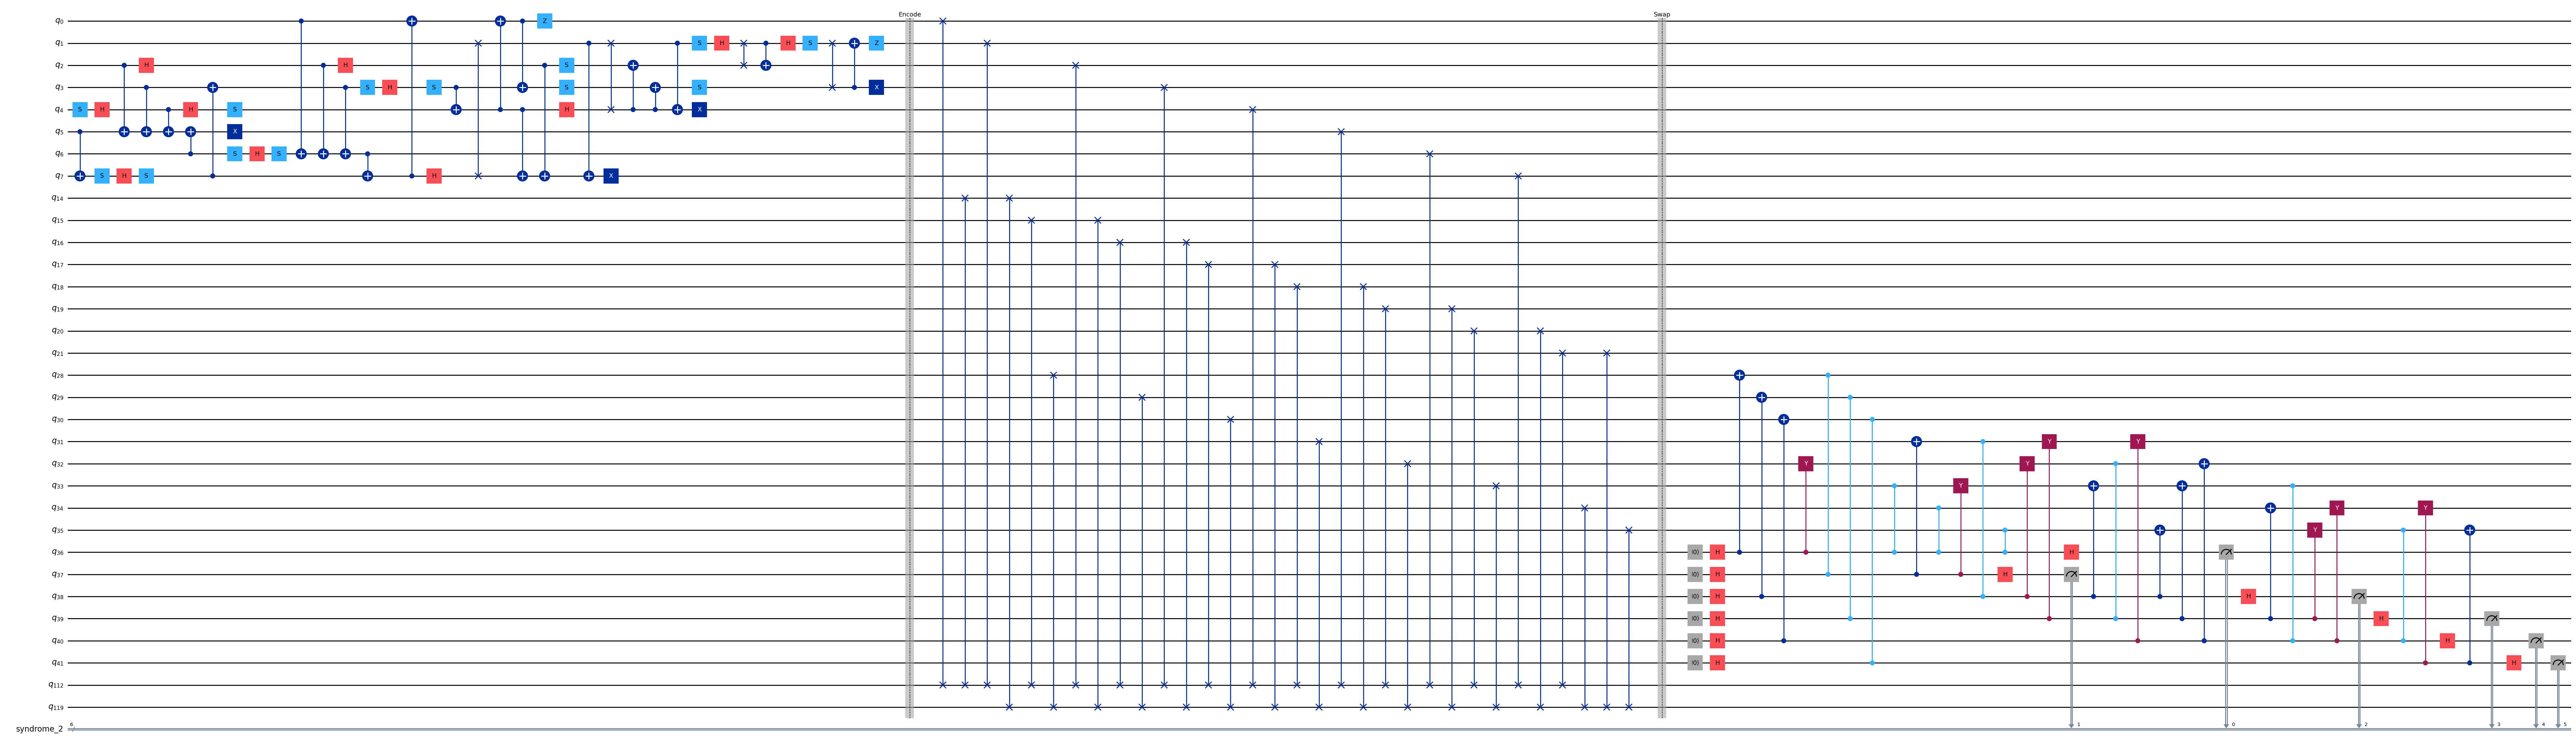

In [ ]:
test_circuit.draw('mpl', fold=-1, idle_wires=False)

Noiseless syndrome counts: {'000000': 4096}


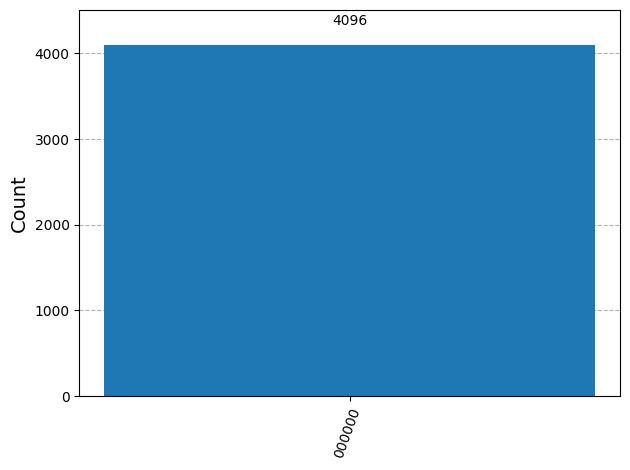

In [ ]:
# =============================================================================
# NOISELESS SIMULATION
# =============================================================================

simulator = AerSimulator(method='matrix_product_state')
transpiled = transpile(test_circuit, basis_gates=BASIS_GATES, optimization_level=OPTIMIZATION_LEVEL)

result = simulator.run(transpiled, shots=NUM_SHOTS).result()
counts = result.get_counts()

print(f"Noiseless syndrome counts: {counts}")
plot_histogram(counts)

Noisy syndrome counts:
{'000000': 3542, '000001': 15, '000010': 12, '000011': 15, '000100': 13, '000101': 1, '000110': 19, '000111': 2, '001000': 16, '001001': 18, '001010': 1, '001100': 15, '001101': 16, '001110': 23, '001111': 1, '010000': 41, '010001': 2, '010010': 1, '010011': 15, '010101': 23, '011000': 24, '011001': 7, '011010': 12, '011100': 15, '011101': 21, '011110': 1, '100000': 33, '100001': 14, '100100': 9, '100111': 7, '101000': 15, '101001': 6, '101011': 1, '101100': 16, '101111': 5, '110000': 48, '110001': 8, '110010': 8, '110100': 6, '110101': 17, '110110': 1, '111000': 22, '111010': 3, '111100': 2, '111101': 3, '111110': 1}


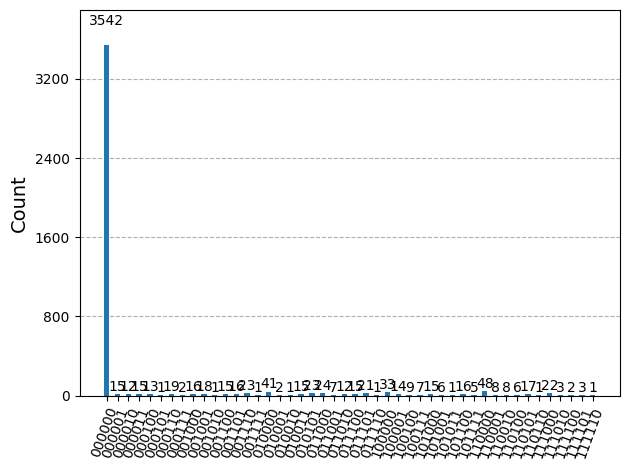

In [ ]:
# =============================================================================
# NOISY SIMULATION
# =============================================================================

noisy_simulator = AerSimulator(noise_model=noise_model, method='matrix_product_state')

noisy_result = noisy_simulator.run(transpiled, shots=NUM_SHOTS).result()
noisy_counts = noisy_result.get_counts()

print("Noisy syndrome counts:")
print(dict(sorted(noisy_counts.items())))
plot_histogram(noisy_counts)

## Data Generation

In [ ]:
# =============================================================================
# DATA GENERATION
# =============================================================================

# Setup simulator
noisy_sim = AerSimulator(noise_model=noise_model, method='matrix_product_state')

measurements = []

print("=" * 60)
print("[[8,2,3]] SYNDROME DATA GENERATION")
print("=" * 60)
print(f"Paths to process: {len(ALL_PATHS)}")
print("=" * 60)

for idx, path in enumerate(ALL_PATHS):
    print(f"\n[{idx+1}/{len(ALL_PATHS)}] Path: {path}")
    
    # Build and transpile
    circuit = build_823_swap_circuit(path, initial_state='00')
    transpiled = transpile(circuit, basis_gates=BASIS_GATES, optimization_level=OPTIMIZATION_LEVEL)
    
    # Run
    result = noisy_sim.run(transpiled, shots=NUM_SHOTS).result()
    counts = result.get_counts()
    
    # Build histogram - entries ordered by syndrome value (000000, 000001, ..., 111111)
    # 6 stabilizers = 2^6 = 64 possible syndromes
    histogram = np.array(
        [counts.get(f"{i:06b}", 0) for i in range(NUM_SYNDROMES_823)],
        dtype=np.float32
    )
    
    # Store
    path_edges = [(path[i], path[i+1]) for i in range(len(path)-1)]
    measurements.append(
        TimeAwareMeasurement(path_edges, histogram, duration=0.0, latency_stats={}, code_type='823'))
    
    no_error_frac = histogram[0] / histogram.sum()
    print(f"  Edges: {path_edges}")
    print(f"  No-error fraction: {no_error_frac:.4f}")

print(f"\n{'=' * 60}")
print(f"Total measurements: {len(measurements)}")
print(f"{'=' * 60}")

## Ground Truth

In [ ]:
# =============================================================================
# GROUND TRUTH CIRCUIT (SWAP-based transport)
# =============================================================================

def build_ground_truth_circuit(source, sink, initial_state='0', measurement_basis='Z'):
    """
    Build a ground truth circuit for single-qubit transport using SWAP chains.
    
    This circuit transports a SINGLE (unencoded) qubit from source to sink
    and measures in the specified basis to determine error rates.
    
    Protocol:
        1. Prepare qubit at source in measurement_basis
        2. SWAP through path qubits to sink
        3. Rotate back to Z-basis and measure
    
    Args:
        source: Source node ID
        sink: Sink node ID
        initial_state: '0' or '1'
        measurement_basis: 'X', 'Y', or 'Z'
    
    Returns:
        QuantumCircuit with measurement
    """
    # Get physical qubit indices
    source_qubits = NODE_PHYSICAL_QUBITS_823[source]
    sink_qubits = NODE_PHYSICAL_QUBITS_823[sink]
    
    # Get path qubit(s) for this edge
    edge_key = (min(source, sink), max(source, sink))
    path_qubits = PATH_PHYSICAL_QUBITS_823[edge_key]
    
    # Create circuit
    qc = QuantumCircuit(TOTAL_QUBITS_823)
    
    # Data qubit is at index 0 within each node's allocation (first logical qubit)
    source_qubit = source_qubits[0]
    sink_qubit = sink_qubits[0]
    
    # Prepare initial state
    if initial_state == '1':
        qc.x(source_qubit)

    # Rotate to measurement basis if needed
    if measurement_basis == 'X':
        qc.h(source_qubit)
    elif measurement_basis == 'Y':
        qc.h(source_qubit)        
        qc.s(source_qubit)

    # Swapping path from source to sink
    num_path_qubits = len(path_qubits)
    qc.swap(source_qubit, path_qubits[0])
    for j in range(num_path_qubits - 1):
        qc.swap(path_qubits[j], path_qubits[j + 1])
    qc.swap(path_qubits[num_path_qubits - 1], sink_qubit)
    
    # Add classical register for measurement
    creg = ClassicalRegister(1, name='c_data')
    qc.add_register(creg)

    # Rotate back before measurement
    if measurement_basis == 'X':
        qc.h(sink_qubit)
    elif measurement_basis == 'Y':
        qc.sdg(sink_qubit)
        qc.h(sink_qubit)    

    qc.measure(sink_qubit, creg[0])

    return qc


def calculate_exact_pauli_rates(z_basis_counts, x_basis_counts, y_basis_counts, expected_state='0'):
    """
    Calculate exact Pauli error rates from three-basis measurements.
    
    For a qubit prepared in |0⟩ and measured in three bases:
    - Z-basis error (measure '1'): X or Y error occurred
    - X-basis error (measure '1'): Z or Y error occurred  
    - Y-basis error (measure '1'): X or Z error occurred
    
    Solving the system:
        E_z = p_x + p_y
        E_x = p_y + p_z
        E_y = p_x + p_z
    
    Gives:
        p_x = (E_z + E_y - E_x) / 2
        p_y = (E_z + E_x - E_y) / 2
        p_z = (E_x + E_y - E_z) / 2
    
    Args:
        z_basis_counts: {'0': n0, '1': n1} from Z-basis measurement
        x_basis_counts: {'0': n0, '1': n1} from X-basis measurement
        y_basis_counts: {'0': n0, '1': n1} from Y-basis measurement
        expected_state: '0' or '1' - the state we prepared
    
    Returns:
        dict with keys 'p_x', 'p_y', 'p_z', 'E_x', 'E_y', 'E_z'
    """
    error_outcome = '1' if expected_state == '0' else '0'
    
    total_z = sum(z_basis_counts.values())
    total_x = sum(x_basis_counts.values())
    total_y = sum(y_basis_counts.values())
    
    E_z = z_basis_counts.get(error_outcome, 0) / total_z
    E_x = x_basis_counts.get(error_outcome, 0) / total_x
    E_y = y_basis_counts.get(error_outcome, 0) / total_y
    
    # Solve for individual Pauli error rates
    p_x = max(0, (E_z + E_y - E_x) / 2)
    p_y = max(0, (E_z + E_x - E_y) / 2)
    p_z = max(0, (E_x + E_y - E_z) / 2)
    
    return {
        'p_x': p_x,
        'p_y': p_y,
        'p_z': p_z,
        'E_x': E_x,
        'E_y': E_y,
        'E_z': E_z
    }

In [ ]:
# =============================================================================
# GROUND TRUTH DATA GENERATION
# =============================================================================
# Generate Pauli error rates for each edge using SWAP-based transport

GROUND_TRUTH_DATA = {}

print("=" * 70)
print("GROUND TRUTH DATA GENERATION (SWAP-based)")
print("=" * 70)
print(f"Using SWAP transport protocol with basis gate decomposition")
print(f"Basis gates: {BASIS_GATES}")
print(f"Edges to process: {list(network_graph.edges())}")
print("=" * 70)

for edge in network_graph.edges():
    print(f"\nEdge {edge}:")
    print(f"  Source qubits: {NODE_PHYSICAL_QUBITS_823[edge[0]][0]}-{NODE_PHYSICAL_QUBITS_823[edge[0]][-1]}")
    print(f"  Sink qubits: {NODE_PHYSICAL_QUBITS_823[edge[1]][0]}-{NODE_PHYSICAL_QUBITS_823[edge[1]][-1]}")
    
    # Build circuits using physical qubit mapping
    circuit_Z = build_ground_truth_circuit(edge[0], edge[1], measurement_basis='Z')
    circuit_X = build_ground_truth_circuit(edge[0], edge[1], measurement_basis='X')
    circuit_Y = build_ground_truth_circuit(edge[0], edge[1], measurement_basis='Y')

    # Transpile to basis gates for proper noise application
    decomposed_Z = transpile(circuit_Z, basis_gates=BASIS_GATES, optimization_level=OPTIMIZATION_LEVEL)
    decomposed_X = transpile(circuit_X, basis_gates=BASIS_GATES, optimization_level=OPTIMIZATION_LEVEL)
    decomposed_Y = transpile(circuit_Y, basis_gates=BASIS_GATES, optimization_level=OPTIMIZATION_LEVEL)

    print("  Running Z-basis measurement...", end=' | ')
    counts_Z = dict(sorted(noisy_sim.run(decomposed_Z, shots=NUM_SHOTS).result().get_counts().items(), key=lambda x: x[0]))
    print("Running X-basis measurement...", end=' | ')
    counts_X = dict(sorted(noisy_sim.run(decomposed_X, shots=NUM_SHOTS).result().get_counts().items(), key=lambda x: x[0]))
    print("Running Y-basis measurement...")
    counts_Y = dict(sorted(noisy_sim.run(decomposed_Y, shots=NUM_SHOTS).result().get_counts().items(), key=lambda x: x[0]))

    error_rates = calculate_exact_pauli_rates(
        z_basis_counts=counts_Z,
        x_basis_counts=counts_X,
        y_basis_counts=counts_Y,
        expected_state='0'
    )

    GROUND_TRUTH_DATA[edge] = [error_rates['p_x'], error_rates['p_y'], error_rates['p_z']]
    print(f"  Pauli Errors: PX={error_rates['p_x']:.6f}, PY={error_rates['p_y']:.6f}, PZ={error_rates['p_z']:.6f}")
    print(f"  Raw error rates: E_x={error_rates['E_x']:.6f}, E_y={error_rates['E_y']:.6f}, E_z={error_rates['E_z']:.6f}")

print(f"\n{'=' * 70}")
print("Ground truth data collection complete")
print(f"{'=' * 70}")

## Save Data

In [ ]:
# =============================================================================
# SAVE DATA
# =============================================================================

os.makedirs(OUTPUT_DIR, exist_ok=True)

with open(os.path.join(OUTPUT_DIR, 'measurements.pkl'), 'wb') as f:
    pickle.dump(measurements, f)

with open(os.path.join(OUTPUT_DIR, 'graph.pkl'), 'wb') as f:
    pickle.dump(network_graph, f)

with open(os.path.join(OUTPUT_DIR, 'ground_truth.pkl'), 'wb') as f:
    pickle.dump(GROUND_TRUTH_DATA, f)

print(f"Data saved to {OUTPUT_DIR}")
print(f"  - measurements.pkl ({len(measurements)} measurements)")
print(f"  - graph.pkl")
print(f"  - ground_truth.pkl ({len(GROUND_TRUTH_DATA)} edges)")
print(f"\nGround truth summary:")
for edge, rates in GROUND_TRUTH_DATA.items():
    print(f"  Edge {edge}: PX={rates[0]:.6f}, PY={rates[1]:.6f}, PZ={rates[2]:.6f}")

## Analysis Summary

In [ ]:
# =============================================================================
# ANALYSIS SUMMARY
# =============================================================================

# Find paths with low no-error fraction
print("\n" + "=" * 60)
print("ANALYSIS SUMMARY")
print("=" * 60)

no_error_fractions = [(m.path_edges, m.histogram[0] / m.histogram.sum()) for m in measurements]
no_error_fractions.sort(key=lambda x: x[1])

print("\nTop 10 lowest no-error fraction paths:")
print("-" * 40)
for edges, frac in no_error_fractions[:10]:
    print(f"  {edges}: {frac:.4f}")

print("\nTop 10 highest no-error fraction paths:")
print("-" * 40)
for edges, frac in no_error_fractions[-10:]:
    print(f"  {edges}: {frac:.4f}")

# Check for paths below threshold
threshold = 0.8
low_performance = [(edges, frac) for edges, frac in no_error_fractions if frac < threshold]
print(f"\nPaths with no-error fraction < {threshold}: {len(low_performance)}")
for edges, frac in low_performance:
    print(f"  {edges}: {frac:.4f}")